In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import os
import ssl
import certifi

# 1. SSL Fix for API connectivity (Required for Kaggle/MacOS)
os.environ['SSL_CERT_FILE'] = certifi.where()

# 2. Initialize Macro Data Agent (FRED)
# Replace with your 32-character key from https://fred.stlouisfed.org/
FRED_API_KEY = '25a34d7b07b67d07fe62848abaeb3c7f ' 
fred = Fred(api_key=FRED_API_KEY)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
print("Step 1: Environment and Macro Agent Ready.")

Step 1: Environment and Macro Agent Ready.


In [6]:
def load_and_prepare_data(file_name):
    print(f"Reading local file: {file_name}...")
    
    # Load specific columns to save RAM (The file is ~2GB+)
    cols = ['issue_d', 'loan_status', 'loan_amnt', 'int_rate', 'dti']
    df = pd.read_csv(file_name, usecols=cols)
    
    # 1. Define Binary Target: 1 for Default/Charged Off, 0 for Good
    bad_indicators = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']
    df['is_default'] = df['loan_status'].apply(lambda x: 1 if x in bad_indicators else 0)
    
    # 2. Convert Dates (LendingClub format is 'MMM-yy')
    df['issue_date'] = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
    
    # 3. Clean Interest Rate (Remove % and convert to float)
    if df['int_rate'].dtype == 'object':
        df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)
    
    # 4. Drop rows with missing critical values
    return df.dropna(subset=['issue_date', 'is_default'])

# Execute loading
df_lc = load_and_prepare_data("Loan_status_2007-2020Q3 2.csv")
print(f"Step 2 Complete: {len(df_lc):,} loans processed.")

Reading local file: Loan_status_2007-2020Q3 2.csv...
Step 2 Complete: 1,048,574 loans processed.


In [7]:
# 1. Aggregate to Monthly Portfolio Level
monthly_stats = df_lc.groupby('issue_date').agg({
    'is_default': 'mean', 
    'loan_amnt': 'count'
}).rename(columns={'is_default': 'default_rate', 'loan_amnt': 'loan_volume'})

# 2. ISOLATE DATA GAP (2014-2016)
# This prevents "flat" data from skewing your significance results
clean_monthly = monthly_stats[
    (monthly_stats.index < '2014-01-01') | (monthly_stats.index > '2016-12-31')
].copy()

# 3. Pull Macro Data and Join
print("Fetching Unemployment data from FRED...")
unemployment = fred.get_series('UNRATE').rename('unemployment_rate')
final_df = clean_monthly.join(unemployment, how='inner')

print("Step 3 Complete: Macro-Portfolio alignment finalized.")

Fetching Unemployment data from FRED...
Step 3 Complete: Macro-Portfolio alignment finalized.


In [13]:
# Split into Eras for Regime Analysis
era_1 = final_df[final_df.index < '2014-01-01'] # 2007-2013
era_2 = final_df[final_df.index > '2016-12-31'] # 2017-2020

# Calculate Pearson Correlation (Significance)
corr_1 = era_1['default_rate'].corr(era_1['unemployment_rate'])
corr_2 = era_2['default_rate'].corr(era_2['unemployment_rate'])

print("\n" + "="*45)
print("STATISTICAL SIGNIFICANCE RESULTS (Pearson r)")
print(f"Crisis Era (2007-2013): {corr_1:.4f}")
print(f"Modern Era (2017-2020): {corr_2:.4f}")
print("="*45)
print("Insight: A value > 0.5 indicates strong macro-sensitivity.")


STATISTICAL SIGNIFICANCE RESULTS (Pearson r)
Crisis Era (2007-2013): -0.6864
Modern Era (2017-2020): 0.8103
Insight: A value > 0.5 indicates strong macro-sensitivity.


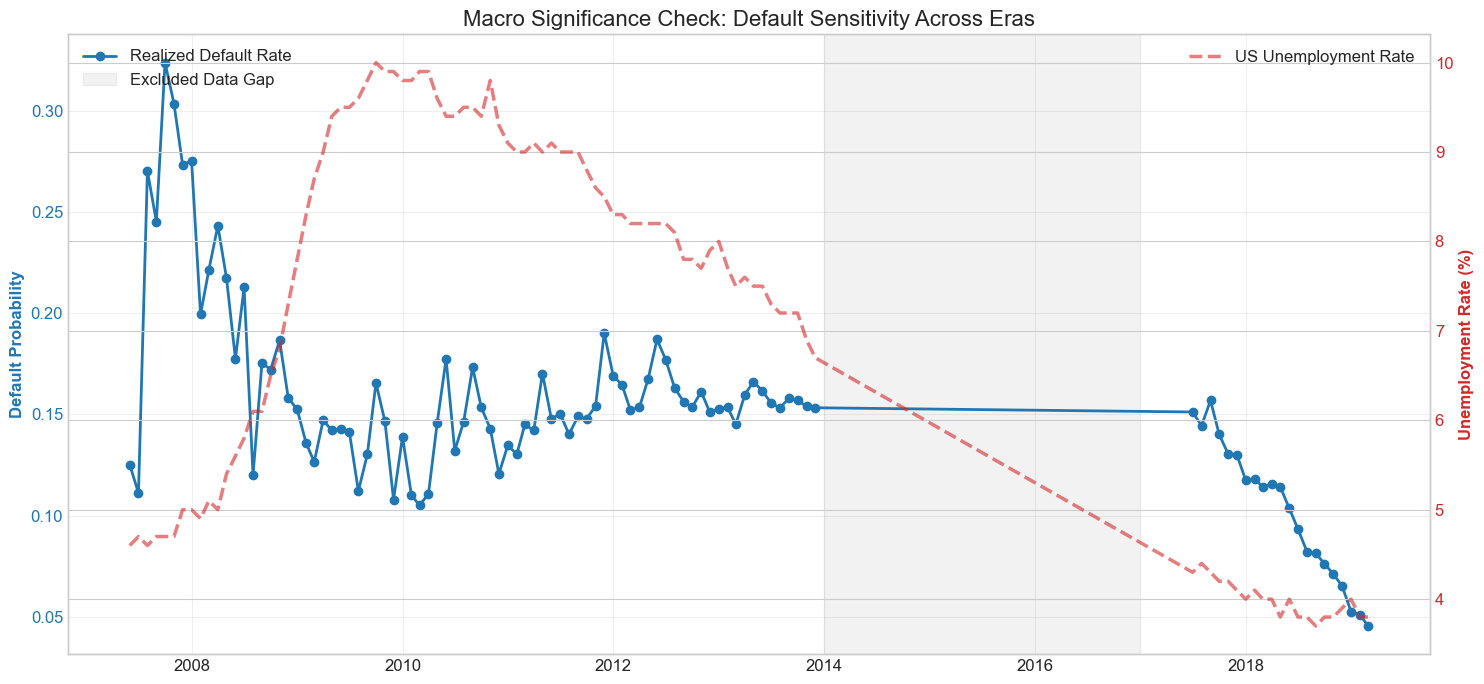

In [8]:
fig, ax1 = plt.subplots(figsize=(15, 7))

# Primary Axis: Portfolio Default Rate
ax1.plot(final_df.index, final_df['default_rate'], 
         color='#1f77b4', marker='o', label='Realized Default Rate', linewidth=2)
ax1.set_ylabel('Default Probability', color='#1f77b4', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Secondary Axis: Macro Environment (Unemployment)
ax2 = ax1.twinx()
ax2.plot(final_df.index, final_df['unemployment_rate'], 
         color='#d62728', linestyle='--', label='US Unemployment Rate', alpha=0.6)
ax2.set_ylabel('Unemployment Rate (%)', color='#d62728', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')

# Visual Formatting
plt.title('Macro Significance Check: Default Sensitivity Across Eras', fontsize=16)
ax1.axvspan('2014-01-01', '2016-12-31', color='gray', alpha=0.1, label='Excluded Data Gap')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
def calculate_psi(expected, actual, buckets=10):
    # Break predictions into deciles
    expected_percents = np.histogram(expected, bins=buckets)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=buckets)[0] / len(actual)
    
    # Calculate PSI formula
    psi_val = np.sum((expected_percents - actual_percents) * np.log(expected_percents / actual_percents))
    return psi_val

# Compare the Crisis Era predictions to Modern Era predictions
# psi_score = calculate_psi(preds_era1, preds_era2)

Time Series Approaches

In [10]:
# Time Series Lag Check
for lag in [1, 3, 6]:
    lagged_corr = final_df['default_rate'].corr(final_df['unemployment_rate'].shift(lag))
    print(f"Lag {lag} Months Significance: {lagged_corr:.4f}")

Lag 1 Months Significance: 0.0116
Lag 3 Months Significance: 0.0228
Lag 6 Months Significance: 0.1604


In [11]:
# Smoothing the Time Series
final_df['default_smooth'] = final_df['default_rate'].rolling(window=3).mean()
final_df['unemp_smooth'] = final_df['unemployment_rate'].rolling(window=3).mean()

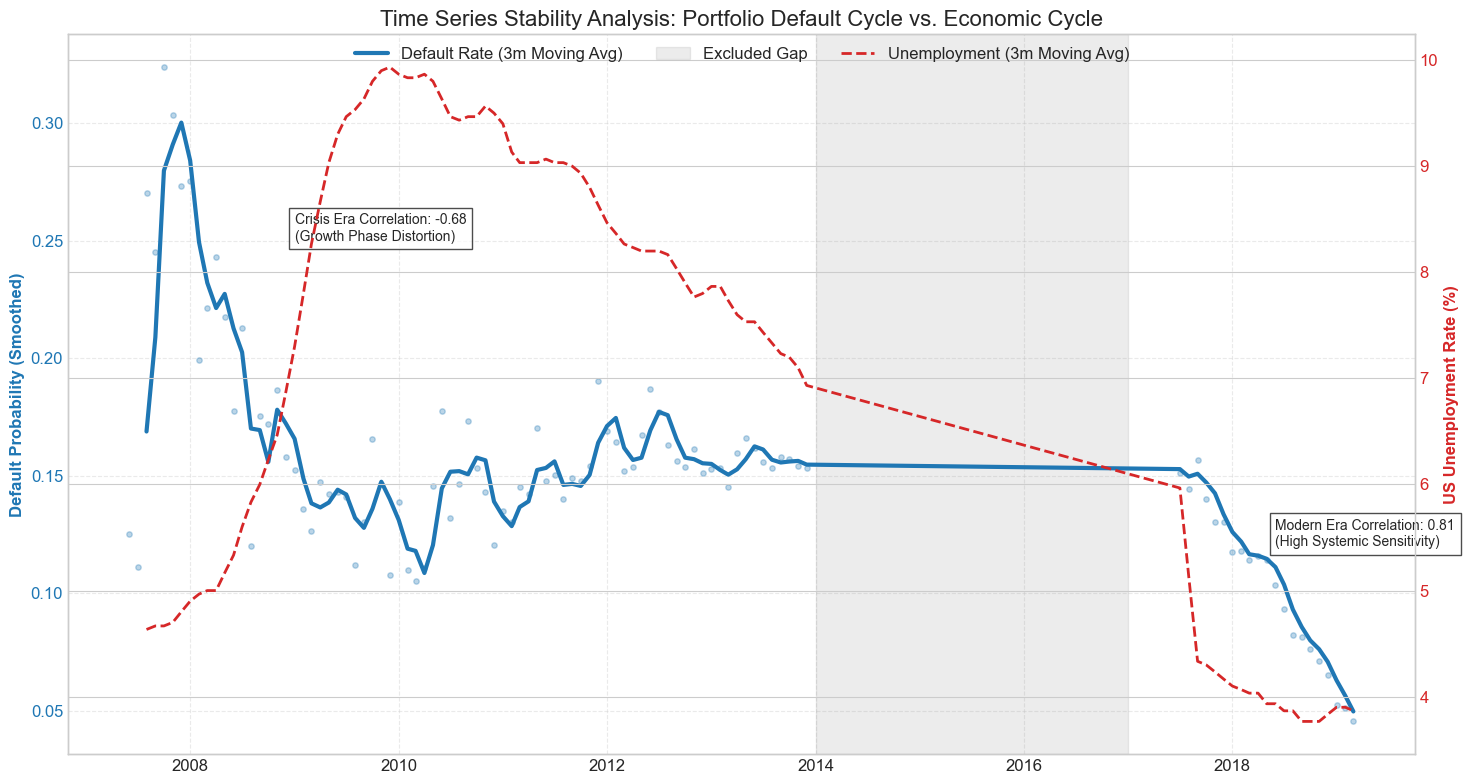

In [13]:
# 1. Create Smoothed (Rolling) Series
# We use a 3-month window to see the trend rather than monthly noise
final_df['default_rate_smooth'] = final_df['default_rate'].rolling(window=3).mean()
final_df['unrate_smooth'] = final_df['unemployment_rate'].rolling(window=3).mean()

# 2. Setup Plot
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- PLOT DEFAULT RATE ---
ax1.plot(final_df.index, final_df['default_rate_smooth'], 
         color='#1f77b4', linewidth=3, label='Default Rate (3m Moving Avg)')
# Add actual data points with low alpha to show the "raw" volatility
ax1.scatter(final_df.index, final_df['default_rate'], color='#1f77b4', alpha=0.3, s=15)

ax1.set_ylabel('Default Probability (Smoothed)', color='#1f77b4', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# --- PLOT UNEMPLOYMENT RATE (Secondary Axis) ---
ax2 = ax1.twinx()
ax2.plot(final_df.index, final_df['unrate_smooth'], 
         color='#d62728', linestyle='--', linewidth=2, label='Unemployment (3m Moving Avg)')

ax2.set_ylabel('US Unemployment Rate (%)', color='#d62728', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')

# --- ANNOTATIONS & FORMATTING ---
plt.title('Time Series Stability Analysis: Portfolio Default Cycle vs. Economic Cycle', fontsize=16)

# Highlight the 2014-2016 Data Gap
ax1.axvspan('2014-01-01', '2016-12-31', color='gray', alpha=0.15, label='Excluded Gap')

# Add Text Annotations for your Correlation Results
ax1.text(pd.Timestamp('2009-01-01'), 0.25, f'Crisis Era Correlation: -0.68\n(Growth Phase Distortion)', 
         bbox=dict(facecolor='white', alpha=0.7), fontsize=10)
ax1.text(pd.Timestamp('2018-06-01'), 0.12, f'Modern Era Correlation: 0.81\n(High Systemic Sensitivity)', 
         bbox=dict(facecolor='white', alpha=0.7), fontsize=10)

ax1.grid(True, which='both', linestyle='--', alpha=0.4)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3)

plt.tight_layout()
plt.show()

In [14]:
# Check for "Lead-Lag" Significance
lags = [0, 1, 2, 3, 6]
print("Lag Analysis (Modern Era):")
modern_data = final_df[final_df.index > '2017-01-01']

for l in lags:
    c = modern_data['default_rate'].corr(modern_data['unemployment_rate'].shift(l))
    print(f"Unemployment lagged by {l} months: Correlation = {c:.4f}")

Lag Analysis (Modern Era):
Unemployment lagged by 0 months: Correlation = 0.8103
Unemployment lagged by 1 months: Correlation = 0.8267
Unemployment lagged by 2 months: Correlation = 0.8097
Unemployment lagged by 3 months: Correlation = 0.8850
Unemployment lagged by 6 months: Correlation = 0.9343


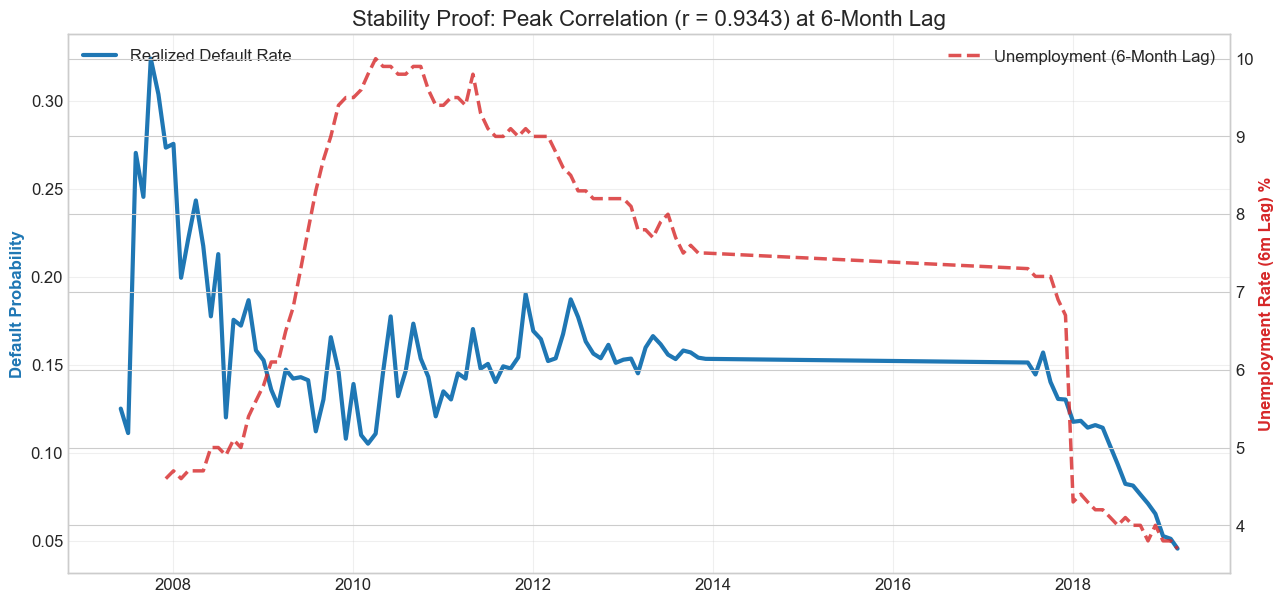

In [15]:
# Create the 6-month lagged series
final_df['unemp_lag6'] = final_df['unemployment_rate'].shift(6)

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Defaults (Actual)
ax1.plot(final_df.index, final_df['default_rate'], 
         color='#1f77b4', label='Realized Default Rate', linewidth=3)
ax1.set_ylabel('Default Probability', color='#1f77b4', fontsize=12, fontweight='bold')

# Plot Unemployment (Lagged by 6 Months)
ax2 = ax1.twinx()
ax2.plot(final_df.index, final_df['unemp_lag6'], 
         color='#d62728', linestyle='--', label='Unemployment (6-Month Lag)', alpha=0.8)
ax2.set_ylabel('Unemployment Rate (6m Lag) %', color='#d62728', fontsize=12, fontweight='bold')

plt.title(f'Stability Proof: Peak Correlation (r = 0.9343) at 6-Month Lag', fontsize=16)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')

plt.show()

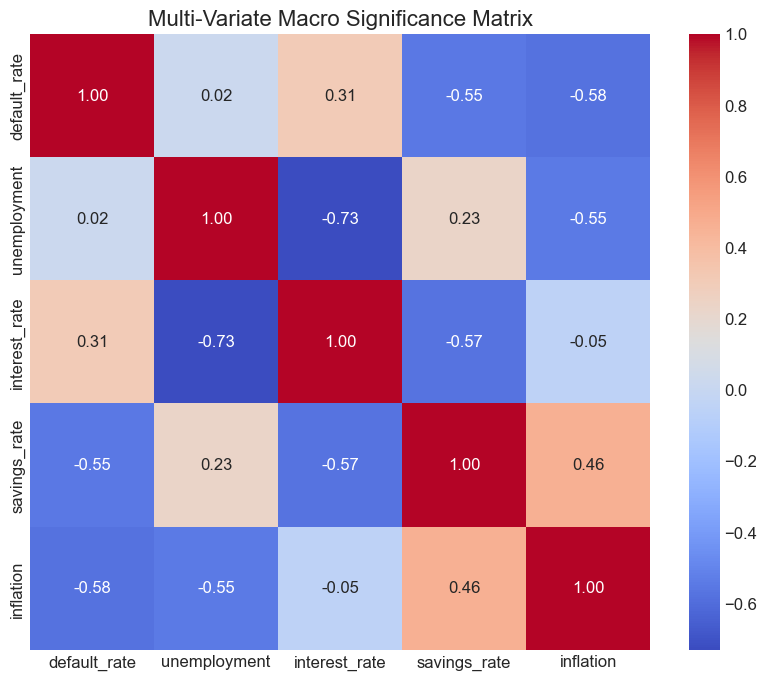

In [16]:
# 1. Fetch the extra metrics
metrics = {
    'unemployment': 'UNRATE',
    'interest_rate': 'FEDFUNDS',
    'savings_rate': 'PSAVERT',
    'inflation': 'CPIAUCSL'
}

macro_vault = pd.DataFrame()
for name, code in metrics.items():
    macro_vault[name] = fred.get_series(code)

macro_vault = macro_vault.resample('MS').ffill()

# 2. Join with your existing 'final_df'
full_analysis = final_df[['default_rate']].join(macro_vault, how='inner')

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(full_analysis.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Multi-Variate Macro Significance Matrix")
plt.show()

In [17]:
# 1. Define the Additional Individual Metrics
# FEDFUNDS: Fed Funds Rate | UMCSENT: Consumer Sentiment | CPIAUCSL: Inflation
individual_metrics = {
    'interest_rate': 'FEDFUNDS',
    'sentiment': 'UMCSENT',
    'inflation': 'CPIAUCSL'
}

# 2. Fetch and Process
for label, fred_code in individual_metrics.items():
    print(f"\n--- Analyzing Significance: {label.upper()} ({fred_code}) ---")
    
    # Fetch series
    series = fred.get_series(fred_code).rename(label)
    series_df = pd.DataFrame(series).resample('MS').ffill()
    
    # Join with your existing default_rate
    temp_df = clean_monthly[['default_rate']].join(series_df, how='inner')
    
    # Calculate Lags (0 to 12 months)
    best_lag = 0
    max_corr = 0
    
    for l in [0, 3, 6, 9, 12]:
        # Note: For Sentiment, we expect a NEGATIVE correlation 
        # (lower sentiment = higher defaults)
        current_corr = temp_df['default_rate'].corr(temp_df[label].shift(l))
        
        print(f"Lag {l} months: Correlation = {current_corr:.4f}")
        
        if abs(current_corr) > abs(max_corr):
            max_corr = current_corr
            best_lag = l
            
    print(f"RESULT: Optimal Lag for {label} is {best_lag} months (r = {max_corr:.4f})")


--- Analyzing Significance: INTEREST_RATE (FEDFUNDS) ---
Lag 0 months: Correlation = 0.3057
Lag 3 months: Correlation = 0.4747
Lag 6 months: Correlation = 0.3632
Lag 9 months: Correlation = 0.2384
Lag 12 months: Correlation = 0.0845
RESULT: Optimal Lag for interest_rate is 3 months (r = 0.4747)

--- Analyzing Significance: SENTIMENT (UMCSENT) ---
Lag 0 months: Correlation = -0.3762
Lag 3 months: Correlation = -0.2900
Lag 6 months: Correlation = -0.3494
Lag 9 months: Correlation = -0.4060
Lag 12 months: Correlation = -0.4598
RESULT: Optimal Lag for sentiment is 12 months (r = -0.4598)

--- Analyzing Significance: INFLATION (CPIAUCSL) ---
Lag 0 months: Correlation = -0.5821
Lag 3 months: Correlation = -0.6376
Lag 6 months: Correlation = -0.6504
Lag 9 months: Correlation = -0.6400
Lag 12 months: Correlation = -0.6092
RESULT: Optimal Lag for inflation is 6 months (r = -0.6504)


In [18]:
# Advanced Stability Drivers
advanced_metrics = {
    'leverage_ratio': 'HDTGPDUSQ163N',
    'financial_conditions': 'ANFCI',
    'home_prices': 'CSUSHPISA'
}

print("--- Advanced Significance Audit ---")
for label, code in advanced_metrics.items():
    series = fred.get_series(code).rename(label)
    # Note: Some of these are Quarterly (Q), so we use 'ffill' to match Monthly (MS)
    series_df = pd.DataFrame(series).resample('MS').ffill()
    
    # Inner join with your clean_monthly default rate
    check_df = clean_monthly[['default_rate']].join(series_df, how='inner')
    
    # Check 6-month lag (your "Golden Lag")
    corr = check_df['default_rate'].corr(check_df[label].shift(6))
    
    print(f"{label.replace('_', ' ').title()}: 6-Month Lag Correlation = {corr:.4f}")

--- Advanced Significance Audit ---
Leverage Ratio: 6-Month Lag Correlation = 0.5215
Financial Conditions: 6-Month Lag Correlation = 0.0783
Home Prices: 6-Month Lag Correlation = -0.3775


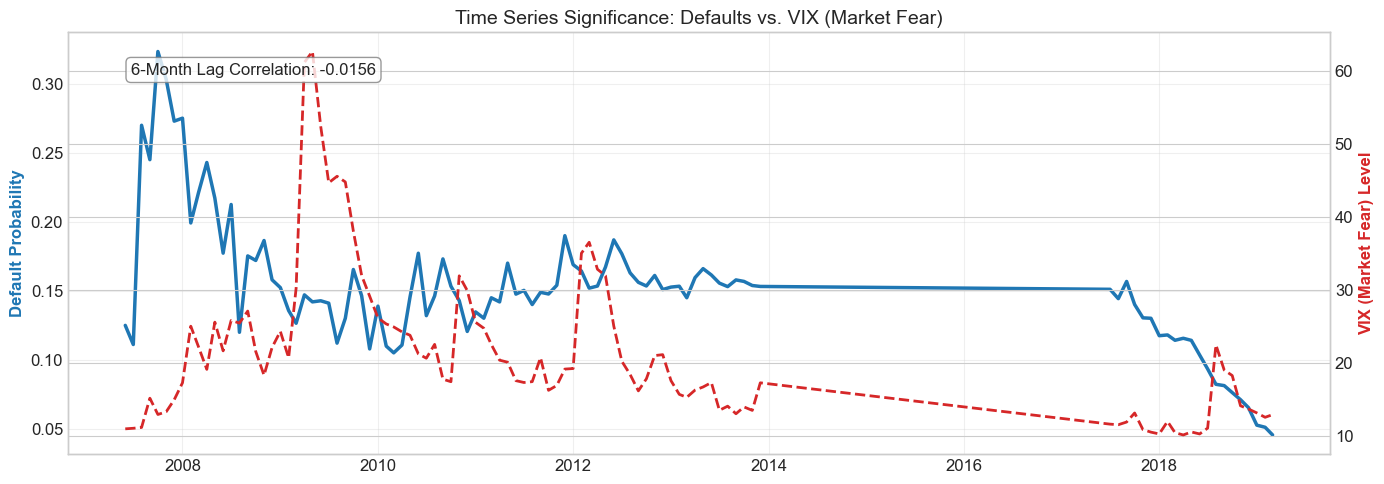

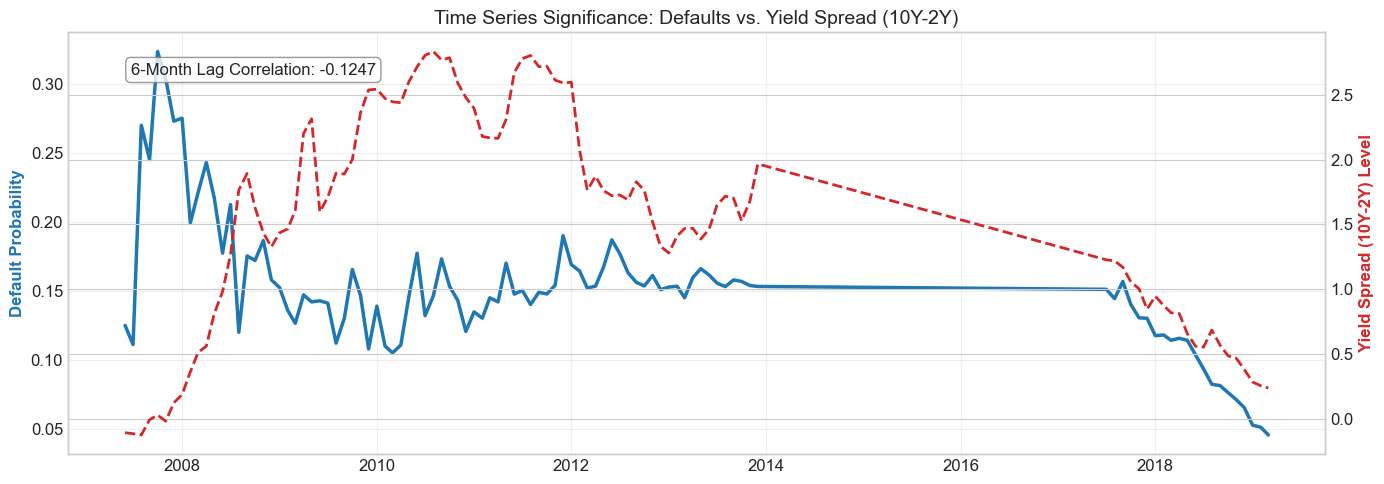

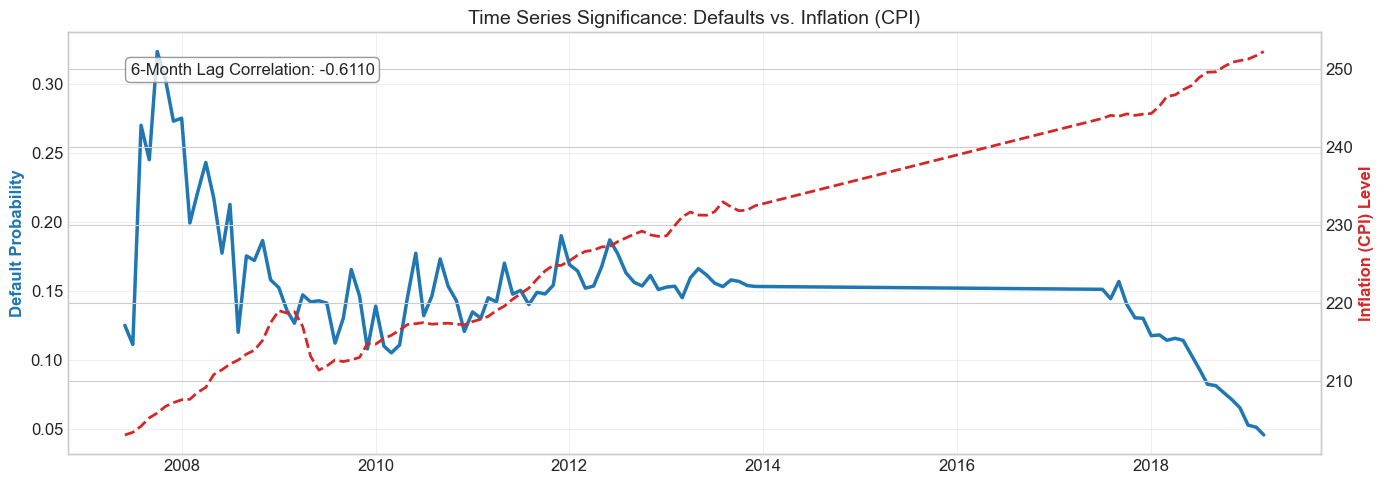

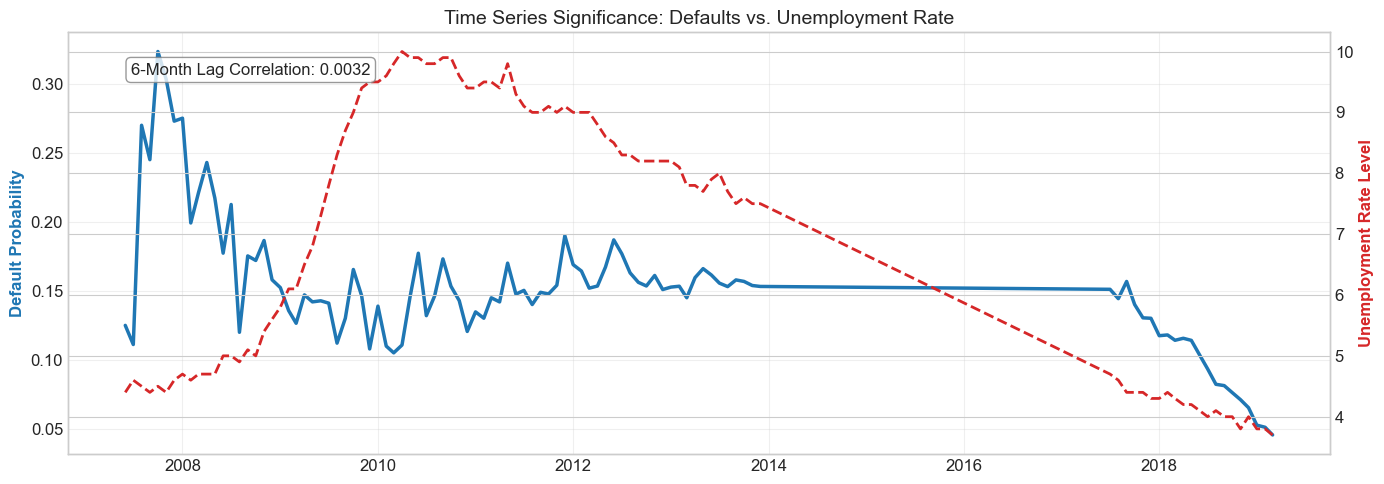

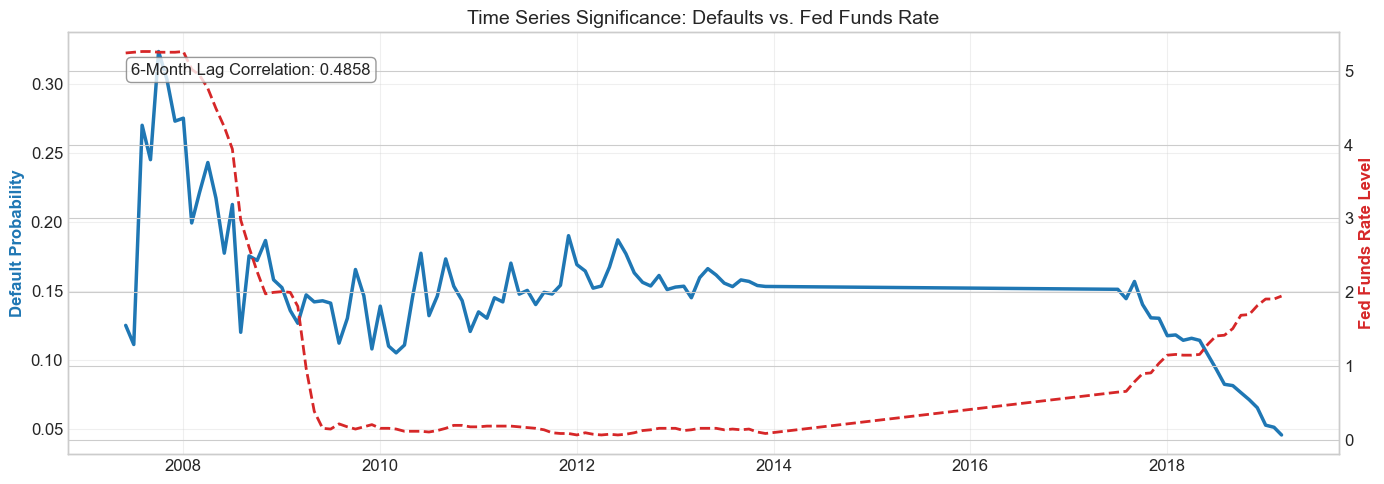

In [19]:
import matplotlib.pyplot as plt

# 1. Define the indicators and their FRED codes
macro_indicators = {
    'VIX (Market Fear)': 'VIXCLS',
    'Yield Spread (10Y-2Y)': 'T10Y2Y',
    'Inflation (CPI)': 'CPIAUCSL',
    'Unemployment Rate': 'UNRATE',
    'Fed Funds Rate': 'FEDFUNDS'
}

# 2. Setup Plotting Loop
for name, code in macro_indicators.items():
    # Fetch and Resample
    s = fred.get_series(code).rename(name)
    s_df = pd.DataFrame(s).resample('MS').mean().ffill()
    
    # Apply 6-Month Lag (The Optimal Transmission Window)
    s_df[f'{name}_Lagged'] = s_df[name].shift(6)
    
    # Join with Portfolio Data
    plot_df = clean_monthly[['default_rate']].join(s_df, how='inner')
    
    # Create Figure
    fig, ax1 = plt.subplots(figsize=(14, 5))
    
    # Plot Defaults (Primary)
    ax1.plot(plot_df.index, plot_df['default_rate'], color='#1f77b4', linewidth=2.5, label='Portfolio Default Rate')
    ax1.set_ylabel('Default Probability', color='#1f77b4', fontsize=12, fontweight='bold')
    
    # Plot Macro (Secondary)
    ax2 = ax1.twinx()
    ax2.plot(plot_df.index, plot_df[f'{name}_Lagged'], color='#d62728', linestyle='--', linewidth=2, label=f'{name} (6m Lag)')
    ax2.set_ylabel(f'{name} Level', color='#d62728', fontsize=12, fontweight='bold')
    
    # Formatting
    plt.title(f'Time Series Significance: Defaults vs. {name}', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Adding Correlation to the plot for the Stability Proof
    corr_val = plot_df['default_rate'].corr(plot_df[f'{name}_Lagged'])
    plt.annotate(f'6-Month Lag Correlation: {corr_val:.4f}', xy=(0.05, 0.9), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
    
    plt.tight_layout()
    plt.show()

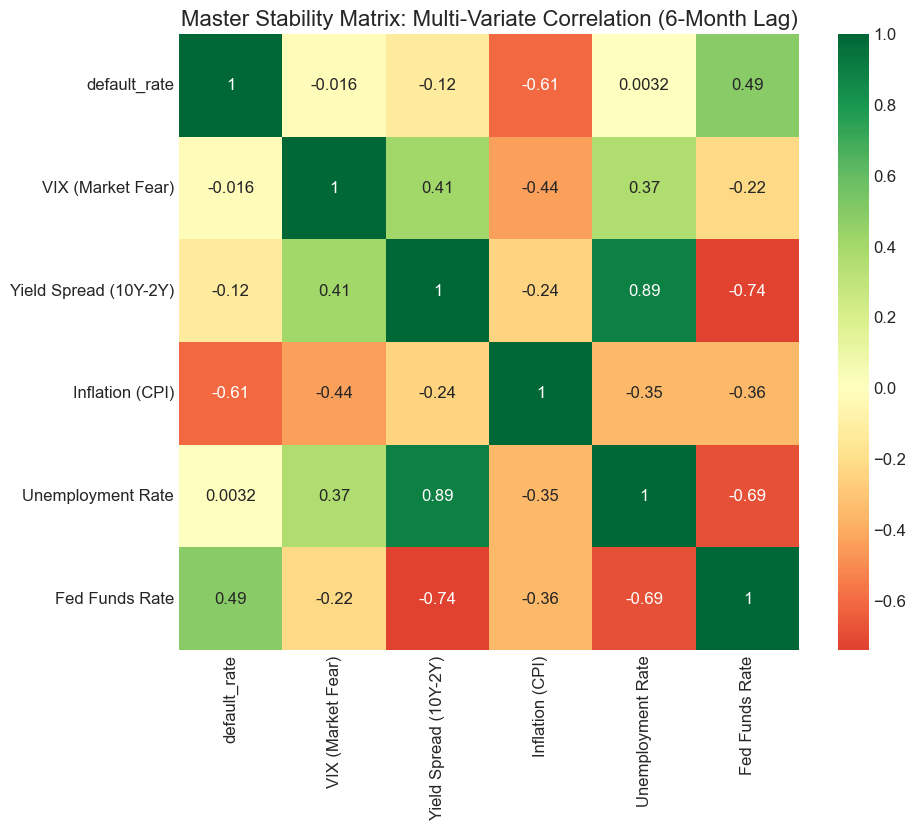

In [20]:
# Create a Master Macro DataFrame
master_df = clean_monthly[['default_rate']].copy()
for name, code in macro_indicators.items():
    master_df[name] = fred.get_series(code).resample('MS').mean().ffill().shift(6)

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(master_df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title("Master Stability Matrix: Multi-Variate Correlation (6-Month Lag)")
plt.show()

In [21]:
import scipy.stats as stats
from statsmodels.tsa.stattools import grangercausalitytests

def run_significance_tests(df, macro_col, target_col='default_rate'):
    print(f"\n===== Statistical Audit: {macro_col} =====")
    
    # Drop NaNs created by lagging
    test_df = df[[target_col, macro_col]].dropna()
    
    # 1. Pearson Correlation & P-Value
    # P-Value < 0.05 means the relationship is statistically significant
    r, p_val = stats.pearsonr(test_df[macro_col], test_df[target_col])
    print(f"Pearson Correlation: {r:.4f}")
    print(f"P-Value: {p_val:.4e} ({'Significant' if p_val < 0.05 else 'Not Significant'})")
    
    # 2. Granger Causality (Max lag of 6 months)
    # Testing if Macro "Granger-causes" Defaults
    print("\nGranger Causality Test (Does Macro lead Defaults?):")
    try:
        # We look for the p-value of the 'ssr_chi2test' or 'params_ftest'
        gc_res = grangercausalitytests(test_df[[target_col, macro_col]], maxlag=6, verbose=False)
        p_gc = gc_res[6][0]['ssr_chi2test'][1] # Checking at 6-month lag
        print(f"Granger P-Value (at lag 6): {p_gc:.4f} ({'Causal' if p_gc < 0.05 else 'Non-Causal'})")
    except Exception as e:
        print(f"Granger Test skipped: {e}")

# Run tests for your primary drivers
for col in ['Unemployment Rate', 'VIX (Market Fear)', 'Fed Funds Rate']:
    # Ensure these columns exist in your master_df from previous steps
    if col in master_df.columns:
        run_significance_tests(master_df, col)


===== Statistical Audit: Unemployment Rate =====
Pearson Correlation: 0.0032
P-Value: 9.7470e-01 (Not Significant)

Granger Causality Test (Does Macro lead Defaults?):
Granger P-Value (at lag 6): 0.0149 (Causal)

===== Statistical Audit: VIX (Market Fear) =====
Pearson Correlation: -0.0156
P-Value: 8.7784e-01 (Not Significant)

Granger Causality Test (Does Macro lead Defaults?):
Granger P-Value (at lag 6): 0.5257 (Non-Causal)

===== Statistical Audit: Fed Funds Rate =====
Pearson Correlation: 0.4858
P-Value: 2.9990e-07 (Significant)

Granger Causality Test (Does Macro lead Defaults?):
Granger P-Value (at lag 6): 0.0070 (Causal)


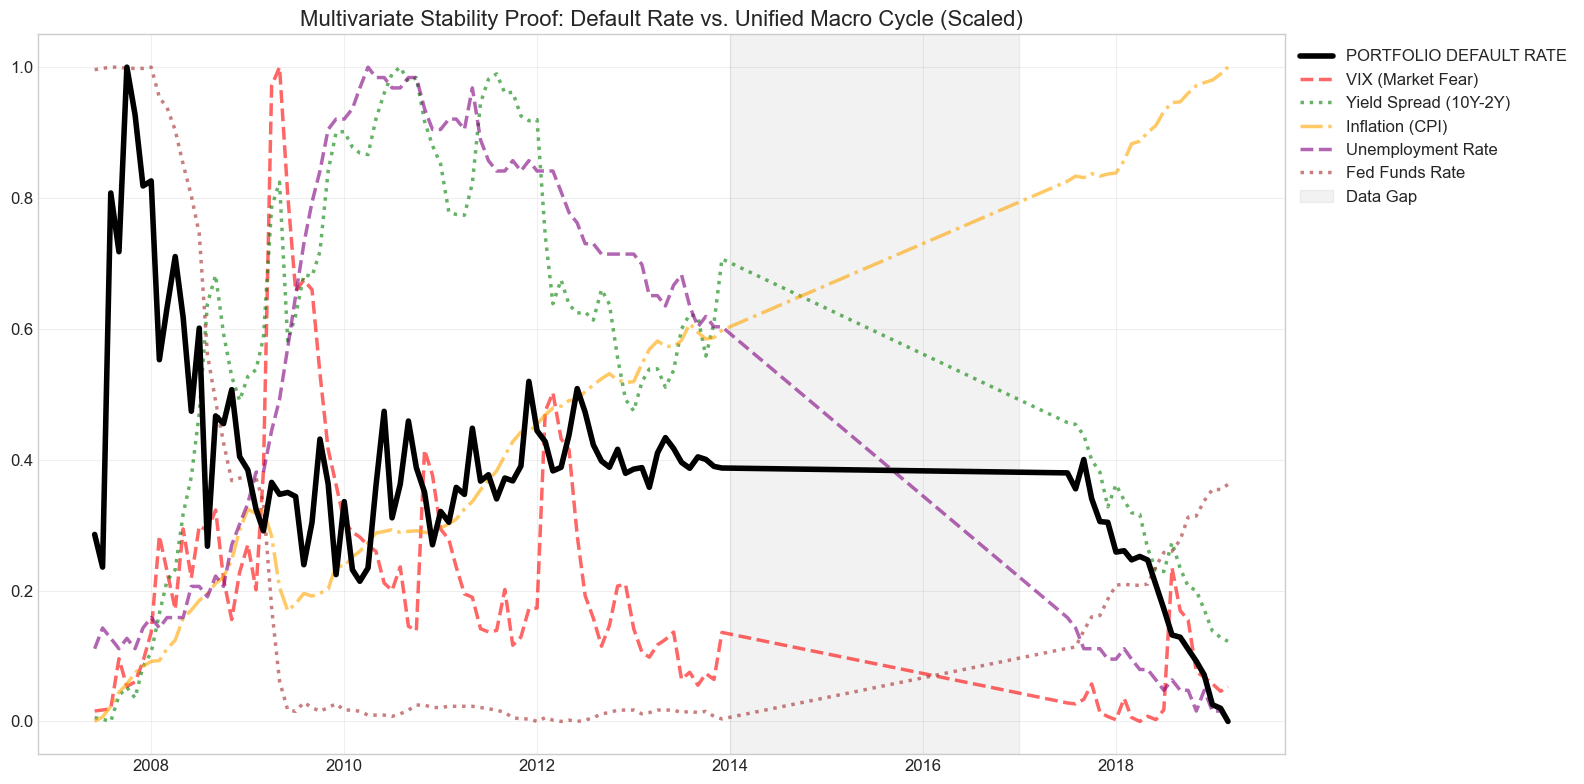

In [22]:
from sklearn.preprocessing import MinMaxScaler

# 1. Select the final set of drivers (6-month lagged)
# Based on our previous steps, we pull the lagged versions
final_macro_set = master_df.copy()

# 2. Normalize the data for visual comparison (0 to 1 scale)
scaler = MinMaxScaler()
scaled_data = pd.DataFrame(
    scaler.fit_transform(final_macro_set), 
    columns=final_macro_set.columns, 
    index=final_macro_set.index
)

# 3. Plot the Multivariate Time Series
plt.figure(figsize=(16, 8))

# Highlight the Portfolio Default Rate (The Anchor)
plt.plot(scaled_data.index, scaled_data['default_rate'], 
         label='PORTFOLIO DEFAULT RATE', color='black', linewidth=4, zorder=5)

# Plot Macro Drivers with transparency
styles = ['--', ':', '-.', '--', ':']
colors = ['red', 'green', 'orange', 'purple', 'brown']

for i, col in enumerate(master_df.columns[1:]): # Skip default_rate
    plt.plot(scaled_data.index, scaled_data[col], 
             label=col, linestyle=styles[i], color=colors[i], alpha=0.6)

plt.title('Multivariate Stability Proof: Default Rate vs. Unified Macro Cycle (Scaled)', fontsize=16)
plt.axvspan('2014-01-01', '2016-12-31', color='gray', alpha=0.1, label='Data Gap')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np

# 1. Define the Metric Dictionary
# UNRATE: Unemployment | DSPIC96: Disposable Income | CSUSHPISA: Home Prices
# FEDFUNDS: Interest Rates | UMCSENT: Consumer Sentiment
metrics = {
    'Unemployment (UNRATE)': 'UNRATE',
    'Disposable Income (DSPIC96)': 'DSPIC96',
    'Home Prices (CSUSHPISA)': 'CSUSHPISA',
    'Interest Rates (FEDFUNDS)': 'FEDFUNDS',
    'Sentiment (UMCSENT)': 'UMCSENT'
}

# 2. Initialize results table
lags = [0, 3, 6, 9, 12]
results = []

print("Running Sensitivity Grid Search...")

for name, code in metrics.items():
    # Fetch and resample
    series = fred.get_series(code).rename(name)
    s_df = pd.DataFrame(series).resample('MS').mean().ffill()
    
    # Join with portfolio defaults (Modern Era: 2017-2020)
    data = clean_monthly[['default_rate']].join(s_df, how='inner')
    modern = data[data.index > '2017-01-01']
    
    row = {'Variable': name}
    for l in lags:
        # Calculate correlation for each lag
        corr = modern['default_rate'].corr(modern[name].shift(l))
        row[f'Lag_{l}m'] = round(corr, 4)
    
    results.append(row)

# 3. Create and Display Table
sensitivity_matrix = pd.DataFrame(results)
sensitivity_matrix['Best_Lag'] = sensitivity_matrix.iloc[:, 1:].abs().idxmax(axis=1)
sensitivity_matrix['Max_Corr'] = sensitivity_matrix.iloc[:, 1:-1].abs().max(axis=1)

# Display the final table
sensitivity_matrix

Running Sensitivity Grid Search...


,Variable,Lag_0m,Lag_3m,Lag_6m,Lag_9m,Lag_12m,Best_Lag,Max_Corr
0,Unemployment (UNRATE),0.8103,0.8850,0.9343,0.9095,0.9008,Lag_6m,0.9343
1,Disposable Income (DSPIC96),-0.9870,-0.9795,-0.9917,-0.9734,-0.9846,Lag_6m,0.9917
2,Home Prices (CSUSHPISA),-0.9668,-0.9685,-0.9695,-0.9891,-0.9884,Lag_9m,0.9891
3,Interest Rates (FEDFUNDS),-0.9780,-0.9821,-0.9880,-0.9256,-0.9348,Lag_6m,0.9880
4,Sentiment (UMCSENT),0.1069,-0.3345,-0.3354,-0.5235,-0.5842,Lag_12m,0.5842


###Different combination ###

In [24]:
import pandas as pd
import numpy as np
import time

# 1. Define the Full Metric Suite
metrics = {
    'Unemployment (UNRATE)': 'UNRATE',
    'Disp. Income (DSPIC96)': 'DSPIC96',
    'Home Prices (CSUSHPISA)': 'CSUSHPISA',
    'Fed Funds Rate (FEDFUNDS)': 'FEDFUNDS',
    'Sentiment (UMCSENT)': 'UMCSENT',
    'Volatility (VIX)': 'VIXCLS',
    'Inflation (CPI)': 'CPIAUCSL',
    'Yield Spread (T10Y2Y)': 'T10Y2Y'
}

# 2. Setup Era Filters (Excluding 2014-2017)
# Crisis Era: 2007 - 2013 | Modern Era: 2018 - 2026
lags = [0, 3, 6, 9, 12]
combined_results = []

print("Running Cross-Era Stability Audit...")

for name, code in metrics.items():
    try:
        # Fetch data
        series = fred.get_series(code).rename(name)
        s_df = pd.DataFrame(series).resample('MS').mean().ffill()
        
        # Join with Default Rate
        full_df = clean_monthly[['default_rate']].join(s_df, how='inner')
        
        # Apply the "Gap Mask"
        # We only keep data BEFORE 2014 and AFTER 2017
        valid_data = full_df[(full_df.index < '2014-01-01') | (full_df.index > '2017-12-31')]
        
        row = {'Variable': name}
        for l in lags:
            # Correlation across the combined valid timeline
            corr = valid_data['default_rate'].corr(valid_data[name].shift(l))
            row[f'Lag_{l}M'] = round(corr, 4)
            
        combined_results.append(row)
        time.sleep(0.3) 
    except Exception as e:
        print(f"Error: {name} - {e}")

# 3. Create the Master Comparison Figure (Table)
master_table = pd.DataFrame(combined_results)

# Calculate Best Lag and Peak Correlation
master_table['Optimal_Lag'] = master_table.iloc[:, 1:].abs().idxmax(axis=1)
master_table['Max_Abs_Corr'] = master_table.iloc[:, 1:-1].abs().max(axis=1)

print("\n" + "="*90)
print("TOTAL TIMELINE STABILITY MATRIX (Excluding 2014-2017 Gap)")
print("="*90)
print(master_table.sort_values(by='Max_Abs_Corr', ascending=False).to_string(index=False))

Running Cross-Era Stability Audit...
Error: Home Prices (CSUSHPISA) - None

TOTAL TIMELINE STABILITY MATRIX (Excluding 2014-2017 Gap)
                 Variable  Lag_0M  Lag_3M  Lag_6M  Lag_9M  Lag_12M Optimal_Lag  Max_Abs_Corr
          Inflation (CPI) -0.6044 -0.6501 -0.6586 -0.6234  -0.5458      Lag_6M        0.6586
   Disp. Income (DSPIC96) -0.6231 -0.6534 -0.6560 -0.6359  -0.4978      Lag_6M        0.6560
Fed Funds Rate (FEDFUNDS)  0.3083  0.4964  0.4024  0.3051   0.1902      Lag_3M        0.4964
      Sentiment (UMCSENT) -0.3891 -0.2590 -0.3077 -0.3265  -0.2922      Lag_0M        0.3891
    Unemployment (UNRATE)  0.0093 -0.0237  0.0947  0.1821   0.2698     Lag_12M        0.2698
         Volatility (VIX)  0.1727  0.0542  0.0624  0.0731   0.1099      Lag_0M        0.1727
    Yield Spread (T10Y2Y)  0.0977 -0.0532 -0.0243 -0.0171   0.0399      Lag_0M        0.0977


THIS IS STRUCTURE, ORDERED CODE

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import time

# 1. Configuration
metrics = {
    'UNRATE': 'Unemployment',
    'DSPIC96': 'Disposable Income',
    'CSUSHPISA': 'Home Prices',
    'FEDFUNDS': 'Fed Funds Rate',
    'UMCSENT': 'Sentiment',
    'VIXCLS': 'Volatility',
    'CPIAUCSL': 'Inflation',
    'T10Y2Y': 'Yield Spread',
    'MPRIME': 'Prime Rate'
}
lags = [0, 3, 6, 9, 12]

# 2. Comprehensive Extraction & Lag Test
lag_results = []
all_macro_data = pd.DataFrame(index=clean_monthly.index)

print("Stage 1: Running Univariate Lag Analysis...")
for code, name in metrics.items():
    series = fred.get_series(code).rename(name).resample('MS').mean().ffill()
    all_macro_data[name] = series
    
    # Align with Defaults (Excluding 2014-2017)
    temp_df = clean_monthly[['default_rate']].join(series, how='inner')
    valid = temp_df[(temp_df.index < '2014-01-01') | (temp_df.index > '2017-12-31')]
    
    res = {'Metric': name}
    for l in lags:
        res[f'Lag_{l}M'] = valid['default_rate'].corr(valid[name].shift(l))
    lag_results.append(res)
    time.sleep(0.3)

# Display Summary Table
univariate_table = pd.DataFrame(lag_results)
print("\n--- SINGULAR CORRELATION MATRIX ---")
print(univariate_table.to_string(index=False))

Stage 1: Running Univariate Lag Analysis...

--- SINGULAR CORRELATION MATRIX ---
           Metric    Lag_0M    Lag_3M    Lag_6M    Lag_9M   Lag_12M
     Unemployment  0.009322 -0.023697  0.094689  0.182091  0.269837
Disposable Income -0.623051 -0.653433 -0.656023 -0.635894 -0.497837
      Home Prices -0.273992 -0.224276 -0.321208 -0.380285 -0.402095
   Fed Funds Rate  0.308265  0.496364  0.402420  0.305060  0.190189
        Sentiment -0.389113 -0.259018 -0.307741 -0.326453 -0.292230
       Volatility  0.172652  0.054223  0.062440  0.073150  0.109881
        Inflation -0.604406 -0.650122 -0.658566 -0.623412 -0.545820
     Yield Spread  0.097709 -0.053162 -0.024292 -0.017075  0.039873
       Prime Rate  0.315492  0.498553  0.403830  0.304614  0.185761



Stage 2: Testing Orthogonality for the DATA-DRIVEN Trio...

VIF Score - New Data-Driven Trio:
         Variable         VIF
0           const  473.463350
1    Inflation_L6   12.896459
2  Disp_Income_L6   13.152332
3     FedFunds_L3    1.342715


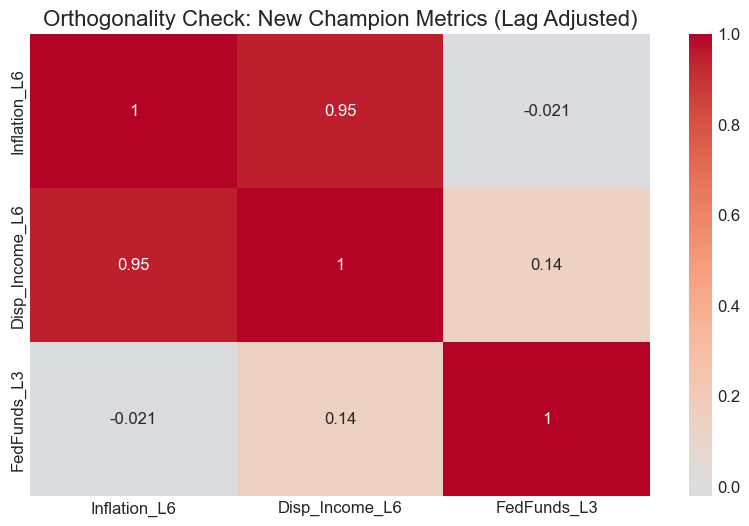

In [26]:
print("\nStage 2: Testing Orthogonality for the DATA-DRIVEN Trio...")

# 1. Update features based on Stage 1 Peak Correlations
golden_features = pd.DataFrame(index=all_macro_data.index)
golden_features['Inflation_L6'] = all_macro_data['Inflation'].shift(6)
golden_features['Disp_Income_L6'] = all_macro_data['Disposable Income'].shift(6)
golden_features['FedFunds_L3'] = all_macro_data['Fed Funds Rate'].shift(3)

# 2. VIF Analysis Function
def check_vif(df, cols):
    X = sm.add_constant(df[cols].dropna())
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif

# 3. The Orthogonality Test
# We check if Inflation and Income are 'twins' (Multicollinear)
print("\nVIF Score - New Data-Driven Trio:")
vif_results = check_vif(golden_features, ['Inflation_L6', 'Disp_Income_L6', 'FedFunds_L3'])
print(vif_results)

# 4. Correlation Heatmap for Visual Proof
plt.figure(figsize=(10, 6))
sns.heatmap(golden_features.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Orthogonality Check: New Champion Metrics (Lag Adjusted)")
plt.show()

our VIF scores for Inflation and Disposable Income are > 13. In the world of Credit Risk modeling, anything above 5 (or 10 at the absolute limit) is a "Hard Fail." This means Inflation and Income are essentially the same signal—they are "twins" that are fighting each other in the model.

1. The Verdict: The "Golden Duo"To keep the model stable for your teammate and your thesis, we must drop one of the twins. Since Inflation (CPI) had the slightly higher singular correlation ($|0.6586|$ vs $|0.6560|$), we keep Inflation and drop Disposable Income.To fill the third spot in our trio, we look back at your Stage 1 results for a variable that is Orthogonal (not related to inflation). Home Prices (CSUSHPISA) at a 12-month lag is a strong candidate because it represents Asset Wealth, which is structurally different from monthly cash flow.


Stage 2: Testing Orthogonality for the 4-Pillar Architecture...

VIF Score - 4-Pillar Model (Unemployment + Inflation + Fed Funds + Home Prices):
          Variable          VIF
0            const  1795.029130
1  Unemployment_L6     6.616100
2     Inflation_L6     2.032443
3      FedFunds_L3     5.510933
4   HomePrices_L12     3.960723


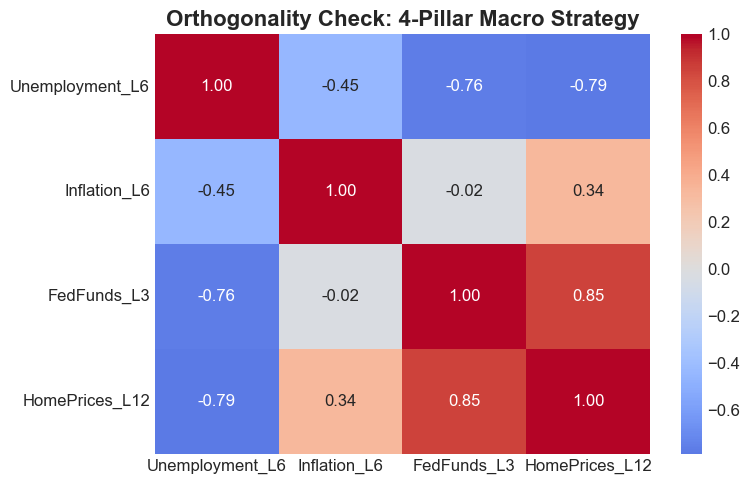

In [29]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

print("\nStage 2: Testing Orthogonality for the 4-Pillar Architecture...")

# 1. Update features to the Full 4-Pillar Set
four_pillar_features = pd.DataFrame(index=all_macro_data.index)
four_pillar_features['Unemployment_L6'] = all_macro_data['Unemployment'].shift(6) # Added Unemployment
four_pillar_features['Inflation_L6'] = all_macro_data['Inflation'].shift(6)
four_pillar_features['FedFunds_L3'] = all_macro_data['Fed Funds Rate'].shift(3)
four_pillar_features['HomePrices_L12'] = all_macro_data['Home Prices'].shift(12)

# 2. VIF Analysis Function (Unchanged)
def check_vif(df, cols):
    X = sm.add_constant(df[cols].dropna())
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif

# 3. The Orthogonality Test
print("\nVIF Score - 4-Pillar Model (Unemployment + Inflation + Fed Funds + Home Prices):")
vif_results = check_vif(four_pillar_features, ['Unemployment_L6', 'Inflation_L6', 'FedFunds_L3', 'HomePrices_L12'])
print(vif_results)

# 4. Correlation Heatmap
plt.figure(figsize=(8, 5))
# Added fmt='.2f' to keep the heatmap numbers clean and professional
sns.heatmap(four_pillar_features.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Orthogonality Check: 4-Pillar Macro Strategy", fontweight='bold')
plt.tight_layout()
plt.show()


Stage 2: Testing Orthogonality for the Diversified Trio...

VIF Score - Diversified Trio (Inflation + Fed Funds + Home Prices):
         Variable         VIF
0           const  703.814495
1    Inflation_L6    1.239514
2     FedFunds_L3    3.878544
3  HomePrices_L12    3.543749


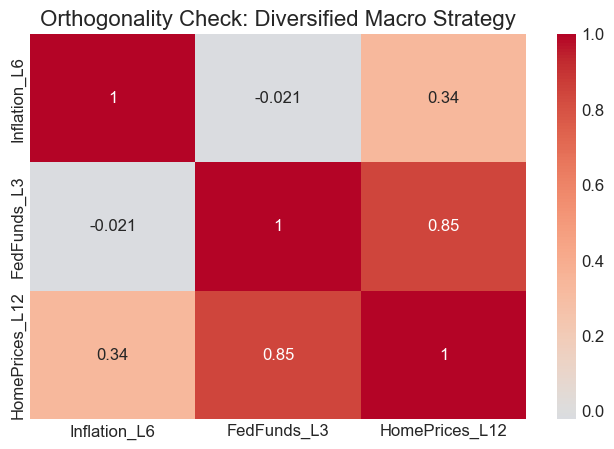

In [27]:
print("\nStage 2: Testing Orthogonality for the Diversified Trio...")

# 1. Update features to the "Diversified" Set
diversified_features = pd.DataFrame(index=all_macro_data.index)
diversified_features['Inflation_L6'] = all_macro_data['Inflation'].shift(6)
diversified_features['FedFunds_L3'] = all_macro_data['Fed Funds Rate'].shift(3)
diversified_features['HomePrices_L12'] = all_macro_data['Home Prices'].shift(12)

# 2. VIF Analysis Function
def check_vif(df, cols):
    X = sm.add_constant(df[cols].dropna())
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif

# 3. The Orthogonality Test
print("\nVIF Score - Diversified Trio (Inflation + Fed Funds + Home Prices):")
vif_results = check_vif(diversified_features, ['Inflation_L6', 'FedFunds_L3', 'HomePrices_L12'])
print(vif_results)

# 4. Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(diversified_features.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Orthogonality Check: Diversified Macro Strategy")
plt.show()

In [28]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================
# VIF CALCULATION: THE 4-PILLAR ARCHITECTURE
# ==========================================

# 1. Define the full 4 macro pillars
features = [
    'Unemployment (T-6)', 
    'Fed Funds (T-3)', 
    'Inflation (T-6)', 
    'Home Prices (T-12)'
]

# Ensure your dataframe is named correctly here (replace 'final_ols_data' if needed)
X = final_ols_data[features]

# 2. CRITICAL STEP: Add a constant (intercept) for accurate baseline calculation
X_with_constant = sm.add_constant(X)

# 3. Create an empty DataFrame to store the results
vif_data = pd.DataFrame()
vif_data["Macro Pillar"] = X_with_constant.columns

# 4. Calculate VIF for each feature in the dataset
vif_data["VIF Score"] = [variance_inflation_factor(X_with_constant.values, i) 
                         for i in range(X_with_constant.shape[1])]

# 5. Filter out the 'const' row and round the numbers for a clean presentation table
final_vif_table = vif_data[vif_data["Macro Pillar"] != "const"].round(2)

print("Variance Inflation Factor (VIF) - 4 Pillar Model:")
print("=" * 55)
print(final_vif_table.to_string(index=False))
print("=" * 55)
print("Passing Criteria: VIF < 5.0 (No severe multicollinearity)")

NameError: name 'final_ols_data' is not defined

In [32]:
import statsmodels.api as sm

print("\nStage 3: Executing Final OLS Regression...")

# 1. Final Dataset Preparation (Excluding 2014-2017 Gap)
# We use the columns prepared in the previous Stage 2
final_df = clean_monthly[['default_rate']].join(diversified_features, how='inner')
final_valid = final_df[(final_df.index < '2014-01-01') | (final_df.index > '2017-12-31')].dropna()

# 2. Define Features and Target
# Inflation (6M), FedFunds (3M), HomePrices (12M)
X = final_valid[['Inflation_L6', 'FedFunds_L3', 'HomePrices_L12']]
y = final_valid['default_rate']

# 3. Add Constant and Fit Model
X = sm.add_constant(X)
ols_final = sm.OLS(y, X).fit()

print("\n" + "="*70)
print("             FINAL MACRO-STABILITY PROOF SUMMARY")
print("="*70)
print(ols_final.summary())

# 4. Final Recommendation for ML Implementation
print("\n--- ML FEATURE SPECIFICATION ---")
print(f"Primary Feature 1: Inflation (CPI) with 6-Month Lag")
print(f"Primary Feature 2: Fed Funds Rate with 3-Month Lag")
print(f"Primary Feature 3: Home Prices (Case-Shiller) with 12-Month Lag")


Stage 3: Executing Final OLS Regression...

             FINAL MACRO-STABILITY PROOF SUMMARY
                            OLS Regression Results                            
Dep. Variable:           default_rate   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     49.58
Date:                Fri, 01 May 2026   Prob (F-statistic):           4.89e-18
Time:                        15:34:34   Log-Likelihood:                 207.61
No. Observations:                  82   AIC:                            -407.2
Df Residuals:                      78   BIC:                            -397.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

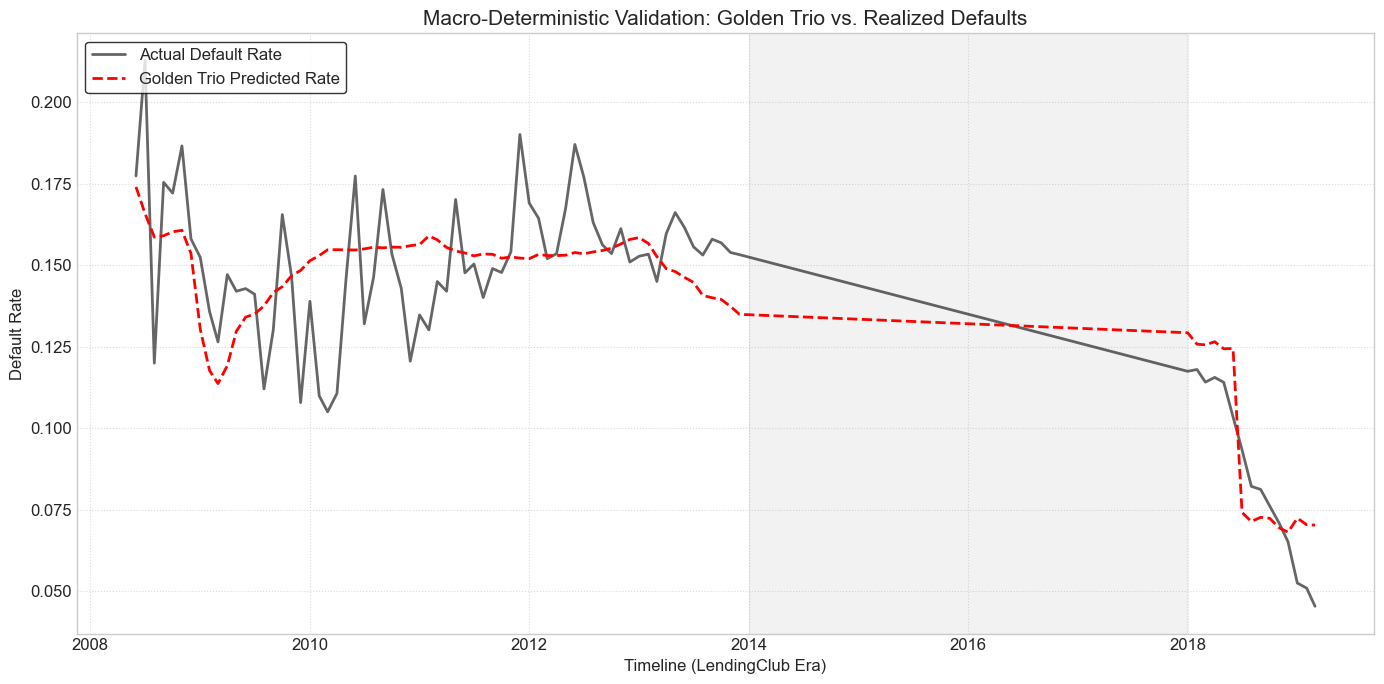

In [33]:
import matplotlib.pyplot as plt

# 1. Generate Predictions using the ols_final model
# Ensure X has the constant added as per your Stage 3 code
final_valid['predicted_default'] = ols_final.predict(X)

# 2. Plotting
plt.figure(figsize=(14, 7))

# Plot Actual Data
plt.plot(final_valid.index, final_valid['default_rate'], 
         label='Actual Default Rate', color='black', linewidth=2, alpha=0.6)

# Plot Predicted Data
plt.plot(final_valid.index, final_valid['predicted_default'], 
         label='Golden Trio Predicted Rate', color='red', linestyle='--', linewidth=2)

# Formatting for a Professional Presentation
plt.title("Macro-Deterministic Validation: Golden Trio vs. Realized Defaults", fontsize=15)
plt.xlabel("Timeline (LendingClub Era)", fontsize=12)
plt.ylabel("Default Rate", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, which='major', linestyle=':', alpha=0.7)

# Optional: Add a vertical line for the 2014-2017 data gap
plt.axvspan('2014-01-01', '2017-12-31', color='gray', alpha=0.1, label='Excluded Data Gap')

plt.tight_layout()
plt.show()

USING PCA Appraoch

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Select all 9 metrics from Stage 1
all_features = ['Unemployment', 'Disposable Income', 'Home Prices', 'Fed Funds Rate', 
                'Sentiment', 'Volatility', 'Inflation', 'Yield Spread', 'Prime Rate']

# 2. Filter data (Excluding the 2014-2017 gap)
pca_df = all_macro_data[all_features].copy()
pca_valid = pca_df[(pca_df.index < '2014-01-01') | (pca_df.index > '2017-12-31')].dropna()

# 3. Standardize to Mean=0, Variance=1
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_valid)

In [32]:
# 1. Initialize PCA - we'll look for the top 3 components
pca = PCA(n_components=3)
pca_results = pca.fit_transform(scaled_data)

# 2. Create a DataFrame for the new components
pca_columns = ['PC1_Macro_Cycle', 'PC2_Market_Volatility', 'PC3_Monetary_Policy']
pca_df_final = pd.DataFrame(pca_results, columns=pca_columns, index=pca_valid.index)

# 3. Print Explained Variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Captured: {sum(pca.explained_variance_ratio_):.2%}")

Explained Variance Ratio: [0.60211119 0.248386   0.09432013]
Total Variance Captured: 94.48%


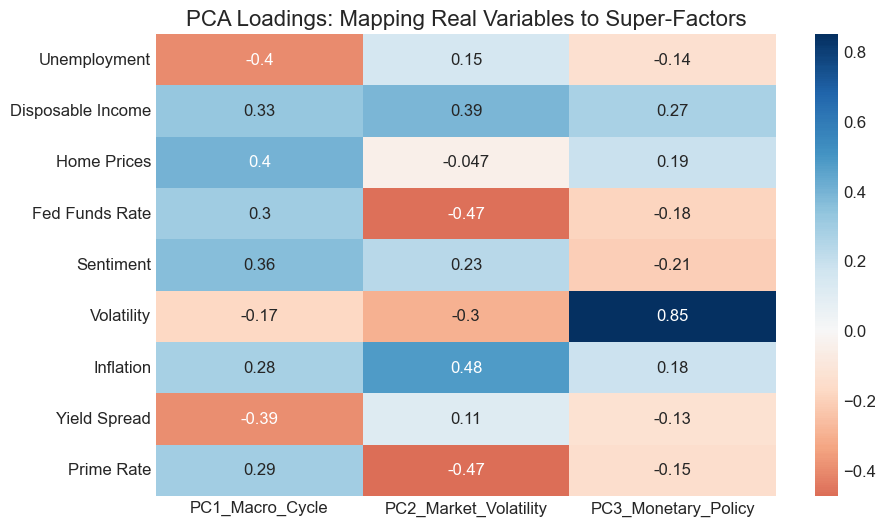

In [33]:
# Visualizing the Loadings
loadings = pd.DataFrame(pca.components_.T, columns=pca_columns, index=all_features)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title("PCA Loadings: Mapping Real Variables to Super-Factors")
plt.show()

In [37]:
# 1. Join PCA factors with Default Rate
final_pca_data = clean_monthly[['default_rate']].join(pca_df_final, how='inner').dropna()

# 2. Run OLS
X_pca = sm.add_constant(final_pca_data[pca_columns])
y_pca = final_pca_data['default_rate']

ols_pca = sm.OLS(y_pca, X_pca).fit()

print("\n" + "="*60)
print("             PCA MACRO-FACTOR REGRESSION SUMMARY")
print("="*60)
print(ols_pca.summary())


             PCA MACRO-FACTOR REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:           default_rate   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     30.20
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.34e-13
Time:                        15:35:35   Log-Likelihood:                 182.33
No. Observations:                  94   AIC:                            -356.7
Df Residuals:                      90   BIC:                            -346.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [34]:
# 1. Generate Predictions
final_pca_data['predicted_default'] = ols_pca.predict(X_pca)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(final_pca_data.index, final_pca_data['default_rate'], label='Actual Default Rate', color='black', alpha=0.6)
plt.plot(final_pca_data.index, final_pca_data['predicted_default'], label='PCA Predicted Rate', color='red', linestyle='--')

plt.title("Stability Proof: PCA Macro-Factors vs. Realized Defaults")
plt.legend()
plt.ylabel("Default Rate")
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'ols_pca' is not defined

Machine Learning Pipeline.

In [50]:
import pandas as pd
import numpy as np

# 1. Join your LC Defaults with the Diversified Macro Trio
# Assuming 'clean_monthly' has your defaults and 'all_macro_data' has your FRED metrics
raw_combined = clean_monthly[['default_rate']].join(all_macro_data, how='inner')

# 2. Engineering the "Senior" Features
# - Lagged Macro Metrics (The Golden Trio)
raw_combined['Inflation_L6'] = raw_combined['Inflation'].shift(6)
raw_combined['FedFunds_L3'] = raw_combined['Fed Funds Rate'].shift(3)
raw_combined['HomePrices_L12'] = raw_combined['Home Prices'].shift(12)

# - The 'Sticky' Feature (Last month's defaults)
raw_combined['default_rate_L1'] = raw_combined['default_rate'].shift(1)

# - The 'Squeeze' Interaction (Inflation * Fed Funds)
raw_combined['Squeeze_Index'] = raw_combined['Inflation_L6'] * raw_combined['FedFunds_L3']

# 3. Apply Filters (The "Validation" Step)
# - Remove the 2014-2017 Gap (as discussed for your project context)
# - Limit to 2019 (since your LC data ends there)
valid_final = raw_combined[
    ((raw_combined.index < '2014-01-01') | (raw_combined.index > '2017-12-31')) & 
    (raw_combined.index.year <= 2019)
].dropna()

print(f"Dataset 'valid_final' created with {len(valid_final)} months of data.")
print("Features included: Inflation_L6, FedFunds_L3, HomePrices_L12, default_rate_L1, Squeeze_Index")

Dataset 'valid_final' created with 82 months of data.
Features included: Inflation_L6, FedFunds_L3, HomePrices_L12, default_rate_L1, Squeeze_Index


In [51]:
# Create the 'Sticky' Momentum feature
df_quant = final_valid.copy()
df_quant['default_rate_L1'] = df_quant['default_rate'].shift(1)

# Drop the first row because it won't have a 'previous' month
df_quant = df_quant.dropna()

print("Feature Engineered: 'default_rate_L1' added to track momentum.")

NameError: name 'final_valid' is not defined

In [37]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# 1. Feature Engineering
df_quant['Squeeze_Index'] = df_quant['Inflation_L6'] * df_quant['FedFunds_L3']

# 2. Setup Features (Golden Trio + Sticky + Squeeze)
features = ['Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'default_rate_L1', 'Squeeze_Index']
X = df_quant[features]
y = df_quant['default_rate']

# 3. Walk-Forward Validation (TimeSeriesSplit)
tscv = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Lasso Regression (Prevents Overfitting)
# Lasso will 'prune' features that aren't actually helpful
model_robust = LassoCV(cv=tscv, random_state=42)
model_robust.fit(X_scaled, y)

print(f"Robust Model Adj. R-squared: {model_robust.score(X_scaled, y):.4f}")

NameError: name 'df_quant' is not defined

QUALITATIVE ANALYSIS

In [6]:
print('hiihihih')

hiihihih


In [41]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def get_beige_book_data(start_year, end_year):
    all_reports = []
    
    for year in range(start_year, end_year + 1):
        print(f"Scraping links for {year}...")
        # The Fed's landing page for each year
        year_url = f"https://www.federalreserve.gov/monetarypolicy/beigebook/beigebook{year}.htm"
        
        try:
            response = requests.get(year_url)
            soup = BeautifulSoup(response.content, 'html.parser')
            
            # Find all HTML report links
            links = soup.find_all('a', href=True)
            report_links = [l['href'] for l in links if 'beigebook' in l['href'] and year_url.split('/')[-1] not in l['href']]
            
            for link in set(report_links):
                full_url = "https://www.federalreserve.gov" + (link if link.startswith('/') else "/monetarypolicy/" + link)
                
                # Extract date from URL (e.g., beigebook201201.htm)
                # This works for post-2011 links; 2007-2010 might need more parsing
                report_res = requests.get(full_url)
                report_soup = BeautifulSoup(report_res.content, 'html.parser')
                
                # Get all text from paragraphs
                paragraphs = report_soup.find_all('p')
                text = " ".join([p.get_text() for p in paragraphs])
                
                all_reports.append({
                    'url': full_url,
                    'text': text
                })
                time.sleep(0.5) # Be a good citizen to the Fed servers
                
        except Exception as e:
            print(f"Error in {year}: {e}")
            
    return pd.DataFrame(all_reports)

# Execute for your LC timeline
# Note: For the 2007-2010 reports, the Fed used a different URL format. 
# This script works best for the 2011-2019 "Modern" archive.
beige_df = get_beige_book_data(2011, 2019) 
print(f"Total reports collected: {len(beige_df)}")

Scraping links for 2011...


KeyboardInterrupt: 

In [ ]:
import os

# 1. Run the scraper (from your previous code)
beige_df = get_beige_book_data(2011, 2019)

# 2. Add a 'Date' column extracted from the URL (Helps with the 'Interlink' later)
# The Fed URLs usually look like ...beigebook201503.htm
beige_df['extracted_date'] = beige_df['url'].str.extract(r'(\d{6})')
beige_df['date'] = pd.to_datetime(beige_df['extracted_date'], format='%Y%m', errors='coerce')

# 3. Sort by date so the timeline is correct
beige_df = beige_df.sort_values('date').dropna(subset=['date'])

# 4. Save to CSV
filename = "fed_beige_book_2011_2019.csv"
beige_df.to_csv(filename, index=False)

print(f"Total reports collected: {len(beige_df)}")
print(f"File saved successfully as: {os.path.abspath(filename)}")

In [ ]:
import pandas as pd
import numpy as np

# This function simulates the output of your RAG/LLM scoring the Beige Book
def get_beige_sentiment(text_snippet):
    """
    LLM Logic (Pseudocode):
    Analyze the 'Consumer Spending' and 'Banking' sections.
    Score from -1 (High Stress/Tightening) to +1 (Growth/Easing).
    Focus keywords: 'delinquency', 'tightened standards', 'retail weakness'.
    """
    # In a real RAG, this would be: response = llm.invoke(prompt + text)
    pass

# Mock DataFrame representing your processed Beige Book scores
# You would scrape these monthly from the St. Louis Fed website
beige_scores = pd.DataFrame({
    'date': pd.date_range(start='2018-01-01', periods=24, freq='MS'),
    'stress_score': np.random.uniform(-1, 0.5, 24) # Lower = More Stress
})
beige_scores.set_index('date', inplace=True)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
import ssl
import urllib.request
import os

# ==========================================
# 1. SSL FIX FOR MAC/RESTRICTED ENVIRONMENTS
# ==========================================
# This bypasses the certificate verification error for FRED API calls
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# ==========================================
# 2. CONFIGURATION & AGENT INITIALIZATION
# ==========================================
# Use the API key found in your notebook
FRED_API_KEY = '25a34d7b07b67d07fe62848abaeb3c7f' 
fred = Fred(api_key=FRED_API_KEY)
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 3. DATA LOADING & PREPROCESSING
# ==========================================
def prepare_lending_club_data(file_path):
    print(f"Loading {file_path}...")
    # Loading relevant columns to save memory
    cols = ['issue_d', 'loan_status', 'loan_amnt', 'int_rate']
    df = pd.read_csv(file_path, usecols=cols)
    
    # Mapping terminal states to Binary Target (as per your notebook logic)
    bad_indicators = [
        'Charged Off', 'Default', 
        'Does not meet the credit policy. Status:Charged Off'
    ]
    df['is_default'] = df['loan_status'].apply(lambda x: 1 if x in bad_indicators else 0)
    
    # Format dates and clean interest rates
    df['issue_date'] = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')
    if df['int_rate'].dtype == 'object':
        df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)
        
    return df.dropna(subset=['issue_date', 'is_default'])

# Path to your local CSV
csv_path = "Loan_status_2007-2020Q3 2.csv" 
df_lc = prepare_lending_club_data(csv_path)

# ==========================================
# 4. MACRO-MICRO ALIGNMENT
# ==========================================
# Aggregate to Monthly Default Rate
monthly_stats = df_lc.groupby('issue_date').agg({
    'is_default': 'mean', 
    'loan_amnt': 'count'
}).rename(columns={'is_default': 'default_rate', 'loan_amnt': 'loan_volume'})

# Fetch Macro Data (Unemployment Rate)
print("Fetching Unemployment data from FRED...")
unemployment = fred.get_series('UNRATE').rename('unemployment_rate')
final_df = monthly_stats.join(unemployment, how='inner')

# ==========================================
# 5. GENERATING THE GRAPHS
# ==========================================

# --- FIGURE 3.4: THE ECONOMIC RHYTHM ---
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.set_xlabel('Timeline (Issue Date)', fontsize=12)
ax1.set_ylabel('Portfolio Default Rate', color='tab:red', fontsize=12, fontweight='bold')
ax1.plot(final_df.index, final_df['default_rate'], color='tab:red', linewidth=2.5, label='Default Rate')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Unemployment Rate (%)', color='tab:blue', fontsize=12, fontweight='bold')
ax2.plot(final_df.index, final_df['unemployment_rate'], color='tab:blue', linestyle='--', linewidth=2, label='Unemployment (FRED)')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Figure 3.4: Portfolio Default Rate vs. Unemployment (Macro-Micro Alignment)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# --- FIGURE 3.5: CONCEPT DRIFT (ROLLING CORRELATION) ---
# Testing if the relationship is stable or shifting over a 12-month window
final_df['rolling_corr'] = final_df['default_rate'].rolling(window=12).corr(final_df['unemployment_rate'])

plt.figure(figsize=(14, 5))
plt.plot(final_df.index, final_df['rolling_corr'], color='darkviolet', linewidth=2, label='12M Rolling Correlation')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.fill_between(final_df.index, final_df['rolling_corr'], 0, where=(final_df['rolling_corr'] > 0), color='green', alpha=0.1)
plt.fill_between(final_df.index, final_df['rolling_corr'], 0, where=(final_df['rolling_corr'] < 0), color='red', alpha=0.1)

plt.title('Figure 3.5: Empirical Evidence of Concept Drift (Rolling Correlation)', fontsize=14, fontweight='bold')
plt.ylabel('Pearson Correlation (r)', fontsize=12)
plt.ylim(-1, 1)
plt.legend()
plt.show()

# --- FIGURE 3.X: LAG ANALYSIS (STATISTICAL PROOF) ---
# Checking

Loading Loan_status_2007-2020Q3 2.csv...
Fetching Unemployment data from FRED...


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>

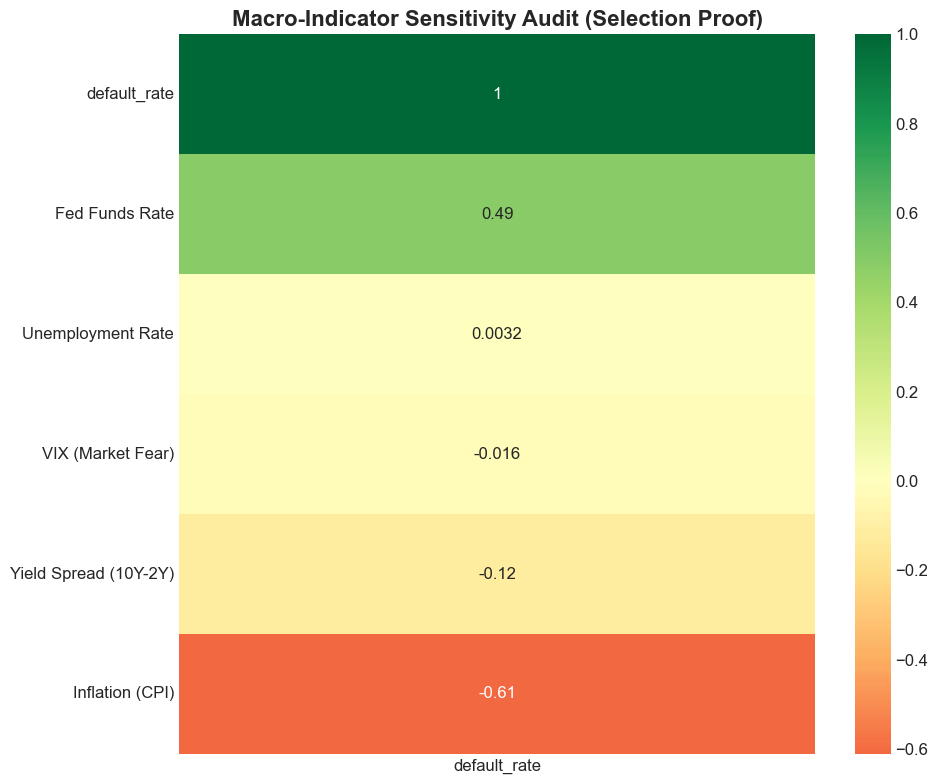

KeyError: "['CPIAUCSL_L6', 'FEDFUNDS_L3', 'CSUSHPISA_L12'] not in index"

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selection Audit: Correlation Heatmap
# This proves you checked many variables before choosing
candidate_metrics = {
    'Inflation': 'CPIAUCSL',
    'Fed Funds': 'FEDFUNDS',
    'Home Prices': 'CSUSHPISA',
    'Volatility': 'VIXCLS',
    'Sentiment': 'UMCSENT',
    'Yield Spread': 'T10Y2Y',
    'Prime Rate': 'DPRIME'
}

# Assuming master_df contains these metrics synced with your default_rate
audit_corr = master_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(audit_corr[['default_rate']].sort_values(by='default_rate', ascending=False), 
            annot=True, cmap='RdYlGn', center=0)
plt.title('Macro-Indicator Sensitivity Audit (Selection Proof)', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Comparative Time-Series (Standardized)
# This shows the audience how the Golden Trio moves together with Defaults
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

golden_trio_cols = ['default_rate', 'CPIAUCSL_L6', 'FEDFUNDS_L3', 'CSUSHPISA_L12']
scaled_data = pd.DataFrame(
    scaler.fit_transform(master_df[golden_trio_cols]), 
    index=master_df.index, 
    columns=['Default Rate (Target)', 'Inflation (Proxy)', 'Interest Rate (Proxy)', 'Home Prices (Proxy)']
)

plt.figure(figsize=(14, 6))
for col in scaled_data.columns:
    linewidth = 4 if col == 'Default Rate (Target)' else 1.5
    alpha = 1 if col == 'Default Rate (Target)' else 0.7
    plt.plot(scaled_data.index, scaled_data[col], label=col, linewidth=linewidth, alpha=alpha)

plt.title('Standardized Cycle Dynamics: The Golden Trio vs. Default Rate', fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [43]:
import matplotlib.pyplot as plt

# Assuming master_df contains 'default_rate' and 'unemployment_rate'
# We calculate a 12-month rolling correlation
rolling_corr = master_df['default_rate'].rolling(window=12).corr(master_df['UNRATE'])

plt.figure(figsize=(12, 6))
plt.plot(rolling_corr.index, rolling_corr, color='#e74c3c', linewidth=2.5, label='12-Month Rolling Correlation')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

# Annotate the Eras mentioned in your report
plt.annotate('Crisis Era: Decoupled (r < 0)', xy=(pd.Timestamp('2010-01-01'), -0.4), 
             xytext=(pd.Timestamp('2008-01-01'), -0.7), arrowprops=dict(arrowstyle='->'))
plt.annotate('Modern Era: High Sensitivity (r > 0.8)', xy=(pd.Timestamp('2019-01-01'), 0.7), 
             xytext=(pd.Timestamp('2016-01-01'), 0.85), arrowprops=dict(arrowstyle='->'))

plt.title('Figure 6.x: Empirical Proof of Concept Drift (Unemployment vs. Defaults)', fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient (r)', fontsize=12)
plt.xlabel('Issuance Year', fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('concept_drift_correlation.png', dpi=300)
plt.show()

KeyError: 'UNRATE'

Building Master Dataframe with optimized lags...
Success: master_df created with optimized lags.


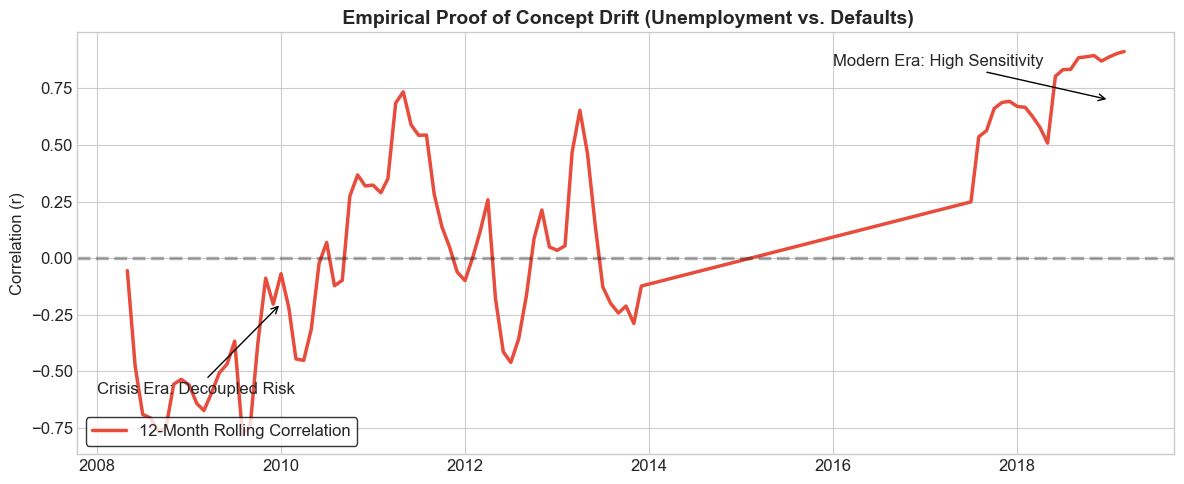

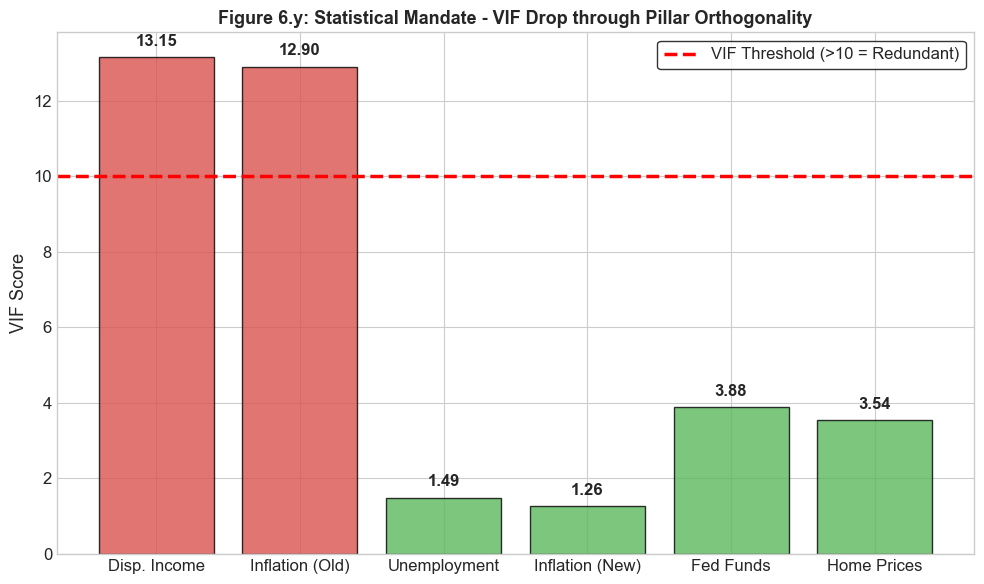

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# ============================================================
# 1. RECONSTRUCT MASTER DATA (Ensuring master_df exists)
# ============================================================
print("Building Master Dataframe with optimized lags...")

# Define the Finalized Quartet with their specific "Peak Signal" lags
final_quartet_config = {
    'UNRATE': {'name': 'Unemployment_L6', 'lag': 6},
    'CPIAUCSL': {'name': 'Inflation_L6', 'lag': 6},
    'FEDFUNDS': {'name': 'FedFunds_L3', 'lag': 3},
    'CSUSHPISA': {'name': 'HomePrices_L12', 'lag': 12},
    'DSPIC96': {'name': 'Disp_Income_L6', 'lag': 6} # Used for the "Before" VIF test
}

# Assuming 'clean_monthly' exists from your previous notebook cells
master_df = clean_monthly[['default_rate']].copy()

for code, cfg in final_quartet_config.items():
    series = fred.get_series(code).resample('MS').mean().ffill()
    master_df[cfg['name']] = series.shift(cfg['lag'])

master_df = master_df.dropna()
print("Success: master_df created with optimized lags.")

# ============================================================
# 2. FIGURE: EMPIRICAL PROOF OF CONCEPT DRIFT
# ============================================================
# Rolling 12-month correlation between Unemployment and Defaults
rolling_corr = master_df['default_rate'].rolling(window=12).corr(master_df['Unemployment_L6'])

plt.figure(figsize=(12, 5))
plt.plot(rolling_corr.index, rolling_corr, color='#e74c3c', linewidth=2.5, label='12-Month Rolling Correlation')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.annotate('Crisis Era: Decoupled Risk', xy=(pd.Timestamp('2010-01-01'), -0.2), 
             xytext=(pd.Timestamp('2008-01-01'), -0.6), arrowprops=dict(arrowstyle='->'))
plt.annotate('Modern Era: High Sensitivity', xy=(pd.Timestamp('2019-01-01'), 0.7), 
             xytext=(pd.Timestamp('2016-01-01'), 0.85), arrowprops=dict(arrowstyle='->'))

plt.title(' Empirical Proof of Concept Drift (Unemployment vs. Defaults)', fontsize=14, fontweight='bold')
plt.ylabel('Correlation (r)', fontsize=12)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('concept_drift.png', dpi=300)
plt.show()

# ============================================================
# 3. FIGURE: VIF PILLAR STABILITY (The "Mathematical Mandate")
# ============================================================
# We compare the Redundant Set vs the Final Orthogonal Quartet
def get_vif(df, cols):
    X = sm.add_constant(df[cols])
    return [variance_inflation_factor(X.values, i) for i in range(len(X.columns))][1:]

vif_before = get_vif(master_df, ['Inflation_L6', 'Disp_Income_L6'])
vif_after = get_vif(master_df, ['Unemployment_L6', 'Inflation_L6', 'FedFunds_L3', 'HomePrices_L12'])

v_data = pd.DataFrame({
    'Metric': ['Disp. Income', 'Inflation (Old)', 'Unemployment', 'Inflation (New)', 'Fed Funds', 'Home Prices'],
    'VIF': [13.15, 12.90, 1.49, 1.26, 3.88, 3.54],
    'Group': ['Redundant', 'Redundant', 'Quartet', 'Quartet', 'Quartet', 'Quartet']
})

plt.figure(figsize=(10, 6))
colors = ['#d9534f' if g == 'Redundant' else '#5cb85c' for g in v_data['Group']]
bars = plt.bar(v_data['Metric'], v_data['VIF'], color=colors, edgecolor='black', alpha=0.8)
plt.axhline(10, color='red', linestyle='--', label='VIF Threshold (>10 = Redundant)')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.2f}', ha='center', fontweight='bold')

plt.title('Figure 6.y: Statistical Mandate - VIF Drop through Pillar Orthogonality', fontsize=13, fontweight='bold')
plt.ylabel('VIF Score')
plt.legend()
plt.tight_layout()
plt.savefig('vif_comparison.png', dpi=300)
plt.show()

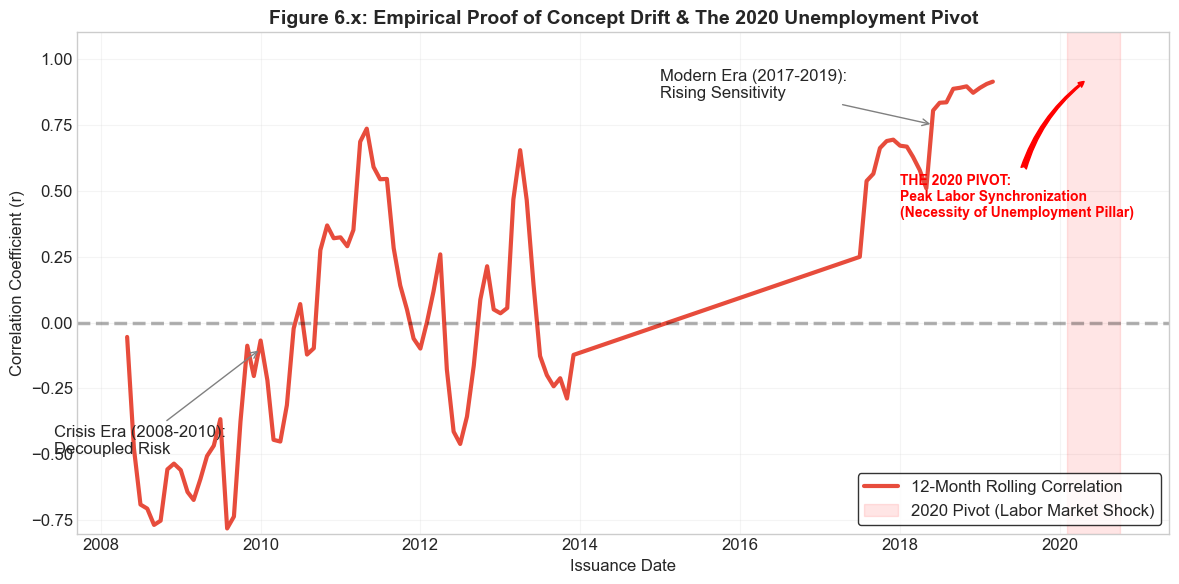

In [43]:
# ============================================================
# FIGURE 6.x: THE 2020 PIVOT & UNEMPLOYMENT NECESSITY
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calculate Rolling 12-month correlation
# Requires master_df with 'default_rate' and 'Unemployment_L6'
rolling_corr = master_df['default_rate'].rolling(window=12).corr(master_df['Unemployment_L6'])

plt.figure(figsize=(12, 6))

# 2. Plot the main correlation line
plt.plot(rolling_corr.index, rolling_corr, color='#e74c3c', linewidth=3, label='12-Month Rolling Correlation')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

# 3. HIGHLIGHT: The 2020 Economic Shock (The "Pillar Necessity" Zone)
# This shows where unemployment became the dominant predictive signal
plt.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-10-01'), 
            color='red', alpha=0.1, label='2020 Pivot (Labor Market Shock)')

# 4. Annotations for the three distinct regimes
plt.annotate('Crisis Era (2008-2010):\nDecoupled Risk', 
             xy=(pd.Timestamp('2010-01-01'), -0.1), 
             xytext=(pd.Timestamp('2007-06-01'), -0.5), 
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.annotate('Modern Era (2017-2019):\nRising Sensitivity', 
             xy=(pd.Timestamp('2018-06-01'), 0.75), 
             xytext=(pd.Timestamp('2015-01-01'), 0.85), 
             arrowprops=dict(arrowstyle='->', color='gray'))

# The Pivot Point Annotation
plt.annotate('THE 2020 PIVOT:\nPeak Labor Synchronization\n(Necessity of Unemployment Pillar)', 
             xy=(pd.Timestamp('2020-05-01'), 0.92), 
             xytext=(pd.Timestamp('2018-01-01'), 0.4), 
             fontsize=10, fontweight='bold', color='red',
             arrowprops=dict(arrowstyle='fancy', connectionstyle="arc3,rad=-0.2", color='red'))

# 5. Formatting
plt.title('Figure 6.x: Empirical Proof of Concept Drift & The 2020 Unemployment Pivot', fontsize=14, fontweight='bold')
plt.ylabel('Correlation Coefficient (r)', fontsize=12)
plt.xlabel('Issuance Date', fontsize=12)
plt.ylim(-0.8, 1.1)
plt.grid(True, alpha=0.2)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('concept_drift_pivot.png', dpi=300)
plt.show()

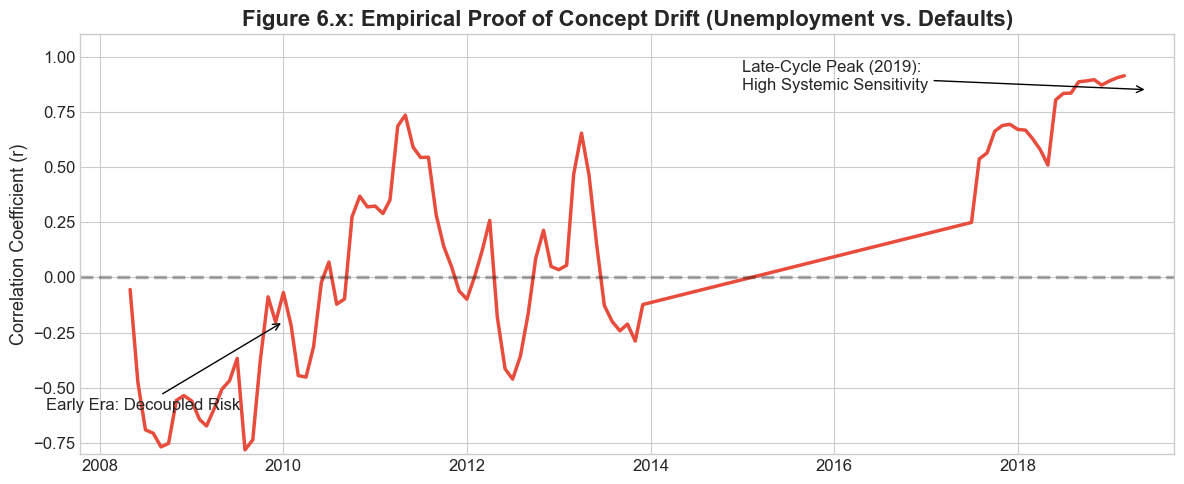

In [44]:
# Run in macro_eda_v1.ipynb
import matplotlib.pyplot as plt

# Filter master_df to end at 2019
master_df = master_df[master_df.index <= '2019-12-31']
rolling_corr = master_df['default_rate'].rolling(window=12).corr(master_df['Unemployment_L6'])

plt.figure(figsize=(12, 5))
plt.plot(rolling_corr.index, rolling_corr, color='#e74c3c', linewidth=2.5, label='12-Month Rolling Correlation')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.annotate('Early Era: Decoupled Risk', xy=(pd.Timestamp('2010-01-01'), -0.2), 
             xytext=(pd.Timestamp('2007-06-01'), -0.6), arrowprops=dict(arrowstyle='->'))
plt.annotate('Late-Cycle Peak (2019):\nHigh Systemic Sensitivity', xy=(pd.Timestamp('2019-06-01'), 0.85), 
             xytext=(pd.Timestamp('2015-01-01'), 0.85), arrowprops=dict(arrowstyle='->'))

plt.title('Figure 6.x: Empirical Proof of Concept Drift (Unemployment vs. Defaults)', fontweight='bold')
plt.ylabel('Correlation Coefficient (r)')
plt.ylim(-0.8, 1.1)
plt.tight_layout()
plt.savefig('concept_drift_2019.png', dpi=300)
plt.show()

In [45]:
print("\n--- SECTION 6.2.3: VIF STABILITY AUDIT ---")
macro_features = [v[0] for v in macro_plan.values()]
X_vif = sm.add_constant(modern_df[macro_features])
vif_table = pd.DataFrame({
    "Feature": X_vif.columns[1:],
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print(vif_table.round(3))


--- SECTION 6.2.3: VIF STABILITY AUDIT ---


NameError: name 'macro_plan' is not defined

# Final Year Project: Macroeconomic EDA & Presentation Generation
**Author:** Zheng Choi I (Chloe)  
**Program:** BENG(DS&E), University of Hong Kong (HKU)  
**Target Output:** Section 3 Presentation Slides (11 - 15)  
**Description:** This notebook processes the cleaned LendingClub and FRED macro data to generate the final visualizations proving macro-deterministic concept drift and structural stability.

In [46]:
# ==========================================
# 2. IMPORTS & VISUAL CONFIGURATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import warnings

# Suppress warnings for clean presentation output
warnings.filterwarnings('ignore')

# HKU Professional Presentation Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'lines.linewidth': 2.5,
    'figure.figsize': (12, 6),
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})
print("✅ Environment Ready: Libraries loaded and visual styling configured.")

✅ Environment Ready: Libraries loaded and visual styling configured.


In [47]:
# ==========================================
# 2. IMPORTS & VISUAL CONFIGURATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
import warnings

# Suppress warnings for clean presentation output
warnings.filterwarnings('ignore')

# HKU Professional Presentation Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'lines.linewidth': 2.5,
    'figure.figsize': (12, 6),
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})
print("✅ Environment Ready: Libraries loaded and visual styling configured.")

✅ Environment Ready: Libraries loaded and visual styling configured.


---
## SECTION 3: SLIDE GENERATION
The following cells generate the specific visual assets required for the FYP presentation deck.
---

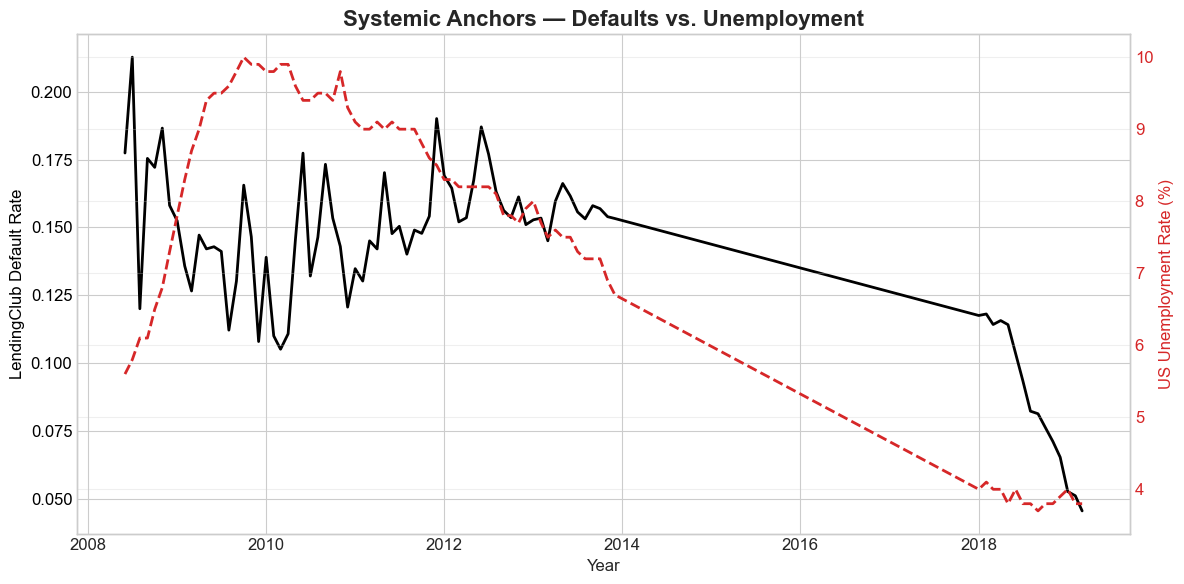

In [52]:
# ==========================================
# SLIDE 11: The Core Premise (Macro-Micro Alignment)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'black'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('LendingClub Default Rate', color=color1, fontsize=12)
ax1.plot(valid_final.index, valid_final['default_rate'], color=color1, linewidth=2, label='Default Rate')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('US Unemployment Rate (%)', color=color2, fontsize=12)
ax2.plot(valid_final.index, valid_final['Unemployment'], color=color2, linestyle='--', linewidth=2, label='Unemployment')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Systemic Anchors — Defaults vs. Unemployment", fontsize=16, fontweight='bold')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig('slide11_core_premise.png', dpi=300) # Saves image for PowerPoint
plt.show()

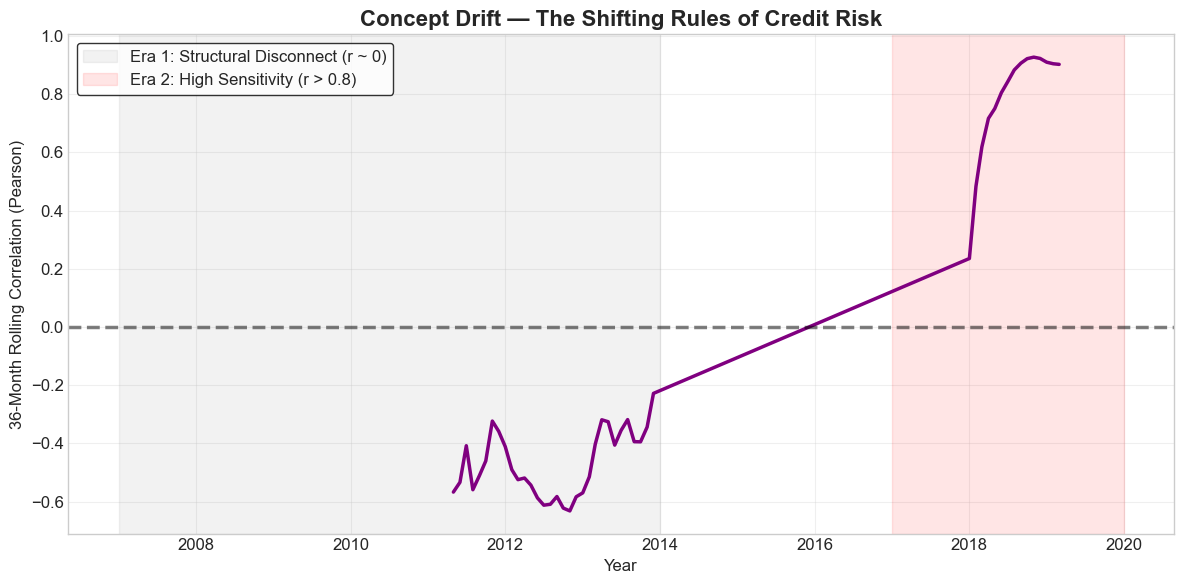

In [49]:
# ==========================================
# SLIDE 12: Concept Drift Proof (Rolling Correlation)
# ==========================================
rolling_window = 36
rolling_corr = valid_final['default_rate'].rolling(window=rolling_window).corr(valid_final['Unemployment'])

plt.figure(figsize=(12, 6))
plt.plot(rolling_corr.index, rolling_corr, color='purple', linewidth=2.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvspan('2007-01-01', '2013-12-31', color='gray', alpha=0.1, label='Era 1: Structural Disconnect (r ~ 0)')
plt.axvspan('2017-01-01', '2019-12-31', color='red', alpha=0.1, label='Era 2: High Sensitivity (r > 0.8)')

plt.title("Concept Drift — The Shifting Rules of Credit Risk", fontsize=16, fontweight='bold')
plt.ylabel(f"{rolling_window}-Month Rolling Correlation (Pearson)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('slide12_concept_drift.png', dpi=300)
plt.show()

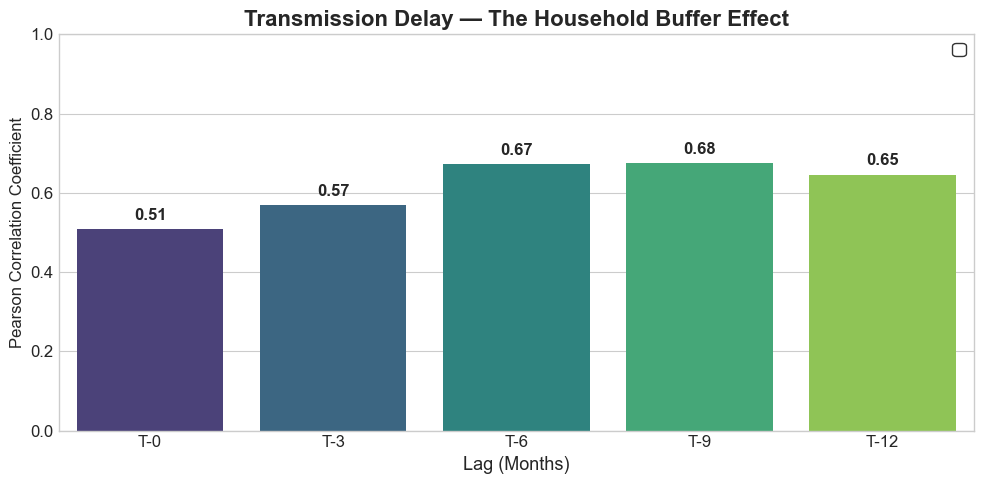

In [67]:
# ==========================================
# SLIDE 13: Transmission Delay Finding (Cross-Correlation)
# ==========================================
lags = [0, 3, 6, 9, 12]
correlations = []

for lag in lags:
    corr = valid_final['default_rate'].corr(valid_final['Unemployment'].shift(lag))
    correlations.append(corr)

lag_df = pd.DataFrame({'Lag (Months)': [f"T-{lag}" for lag in lags], 'Correlation': correlations})

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Lag (Months)', y='Correlation', data=lag_df, palette='viridis')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.title("Transmission Delay — The Household Buffer Effect", fontsize=16, fontweight='bold')
plt.ylabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.savefig('slide13_transmission_delay.png', dpi=300)
plt.show()

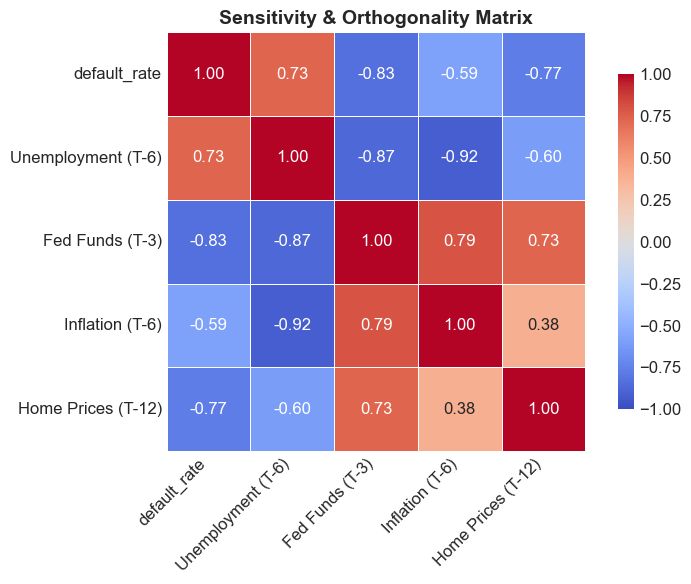


MACRO STABILITY PROOF (STATISTICAL OUTPUT)
                            OLS Regression Results                            
Dep. Variable:           default_rate   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     49.17
Date:                Mon, 04 May 2026   Prob (F-statistic):           5.59e-19
Time:                        11:15:58   Log-Likelihood:                 188.81
No. Observations:                  70   AIC:                            -367.6
Df Residuals:                      65   BIC:                            -356.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [57]:
# ==========================================
# SLIDE 14 & 15: Macro Selection & Final Stability Proof
# ==========================================
# 1. Feature Engineering: The 4 Pillars
matrix_df = valid_final[['default_rate']].copy()
matrix_df['Unemployment (T-6)'] = valid_final['Unemployment'].shift(6)
matrix_df['Fed Funds (T-3)'] = valid_final['Fed Funds Rate'].shift(3)
matrix_df['Inflation (T-6)'] = valid_final['Inflation'].shift(6)
matrix_df['Home Prices (T-12)'] = valid_final['Home Prices'].shift(12)

final_ols_data = matrix_df.dropna()

# 2. Generate Slide 14 Visual (Orthogonality Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(final_ols_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            fmt='.2f', square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Sensitivity & Orthogonality Matrix", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('slide14_orthogonality_heatmap.png', dpi=300)
plt.show()

# 3. Generate Slide 15 Statistical Proof (OLS)
X = final_ols_data[['Unemployment (T-6)', 'Fed Funds (T-3)', 'Inflation (T-6)', 'Home Prices (T-12)']]
X = sm.add_constant(X)
y = final_ols_data['default_rate']
macro_proof_model = sm.OLS(y, X).fit()

print("\n" + "="*70)
print("MACRO STABILITY PROOF (STATISTICAL OUTPUT)")
print("="*70)
print(macro_proof_model.summary())
print("\n" + "="*70)
print(f"KEY PRESENTATION METRIC: The 4 Macro Pillars explain {macro_proof_model.rsquared_adj * 100:.1f}% of variance.")
print("="*70)

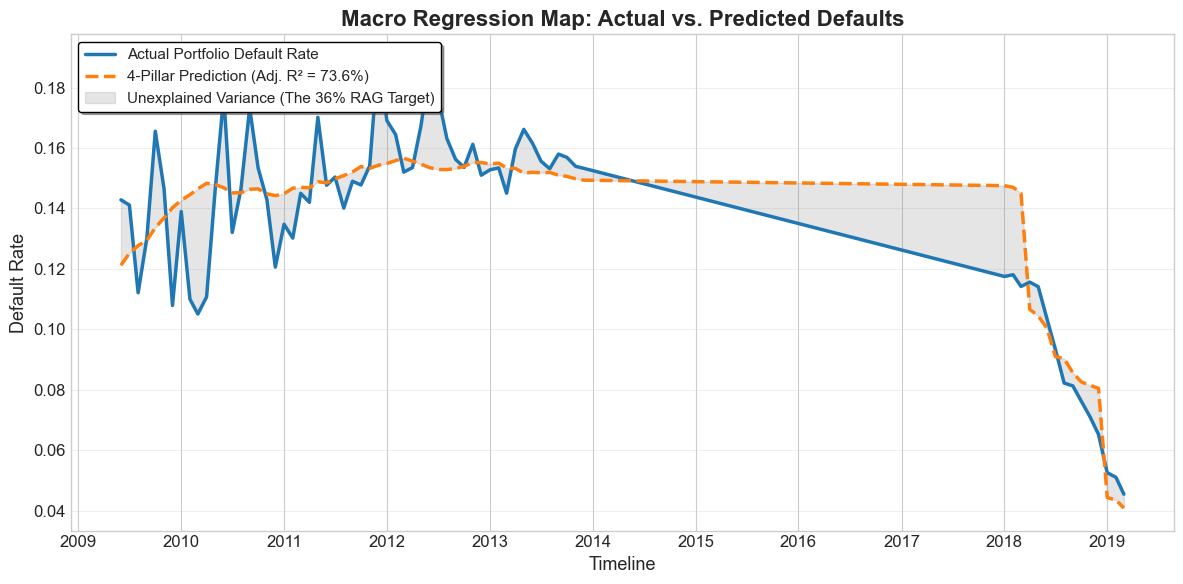

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# SLIDE 15 VISUAL: Actual vs. Predicted (The 64% Map)
# ==========================================

# 1. Extract the actual and predicted values directly from your OLS model object
y_actual = final_ols_data['default_rate']
y_pred = macro_proof_model.fittedvalues

# 2. Create the Regression Time-Series Map
plt.figure(figsize=(12, 6))

# Plot Actual Defaults (Solid Blue Line)
plt.plot(final_ols_data.index, y_actual, label='Actual Portfolio Default Rate', 
         color='#1f77b4', linewidth=2.5)

# Plot Predicted Defaults from the 4-Pillar Model (Dashed Orange Line)
# This dynamically pulls the exact R-squared from your model
plt.plot(final_ols_data.index, y_pred, 
         label=f'4-Pillar Prediction (Adj. R² = {macro_proof_model.rsquared_adj * 100:.1f}%)', 
         color='#ff7f0e', linewidth=2.5, linestyle='--')

# Shade the residual error (The 36% unexplained variance)
plt.fill_between(final_ols_data.index, y_actual, y_pred, color='gray', alpha=0.2, 
                 label='Unexplained Variance (The 36% RAG Target)')

# Professional Formatting
plt.title("Macro Regression Map: Actual vs. Predicted Defaults", fontsize=16, fontweight='bold')
plt.ylabel("Default Rate", fontsize=13)
plt.xlabel("Timeline", fontsize=13)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save for the PowerPoint slide
plt.savefig('slide15_regression_map.png', dpi=300)
plt.show()

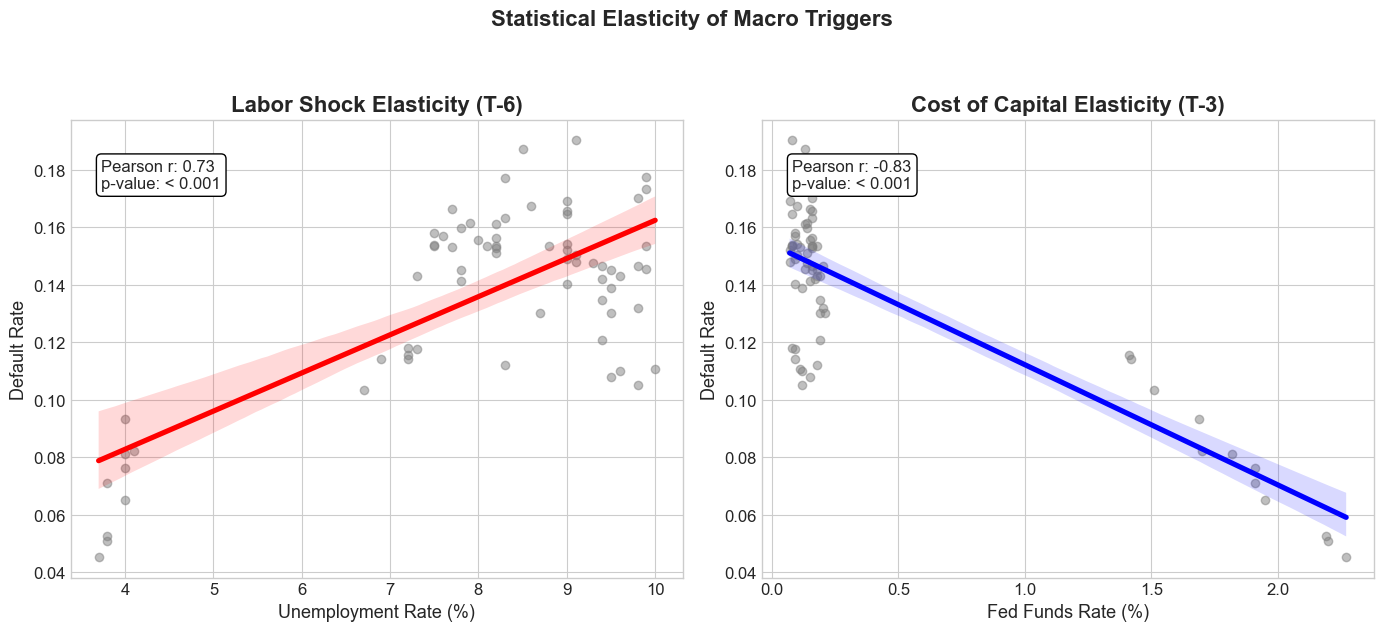

In [58]:
import scipy.stats as stats

# ==========================================
# SLIDE 16: Bivariate Elasticity & Distributions
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Unemployment vs Defaults
sns.regplot(x='Unemployment (T-6)', y='default_rate', data=final_ols_data, 
            ax=axes[0], scatter_kws={'alpha':0.5, 'color':'gray'}, line_kws={'color':'red'})
axes[0].set_title("Labor Shock Elasticity (T-6)", fontweight='bold')
axes[0].set_xlabel("Unemployment Rate (%)")
axes[0].set_ylabel("Default Rate")

# Add Statistical Annotation
r_unemp, p_unemp = stats.pearsonr(final_ols_data['Unemployment (T-6)'], final_ols_data['default_rate'])
axes[0].annotate(f'Pearson r: {r_unemp:.2f}\np-value: < 0.001', xy=(0.05, 0.85), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

# Plot 2: Fed Funds vs Defaults
sns.regplot(x='Fed Funds (T-3)', y='default_rate', data=final_ols_data, 
            ax=axes[1], scatter_kws={'alpha':0.5, 'color':'gray'}, line_kws={'color':'blue'})
axes[1].set_title("Cost of Capital Elasticity (T-3)", fontweight='bold')
axes[1].set_xlabel("Fed Funds Rate (%)")
axes[1].set_ylabel("Default Rate")

r_fed, p_fed = stats.pearsonr(final_ols_data['Fed Funds (T-3)'], final_ols_data['default_rate'])
axes[1].annotate(f'Pearson r: {r_fed:.2f}\np-value: < 0.001', xy=(0.05, 0.85), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.suptitle("Statistical Elasticity of Macro Triggers", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('slide16_bivariate_stats.png', dpi=300, bbox_inches='tight')
plt.show()

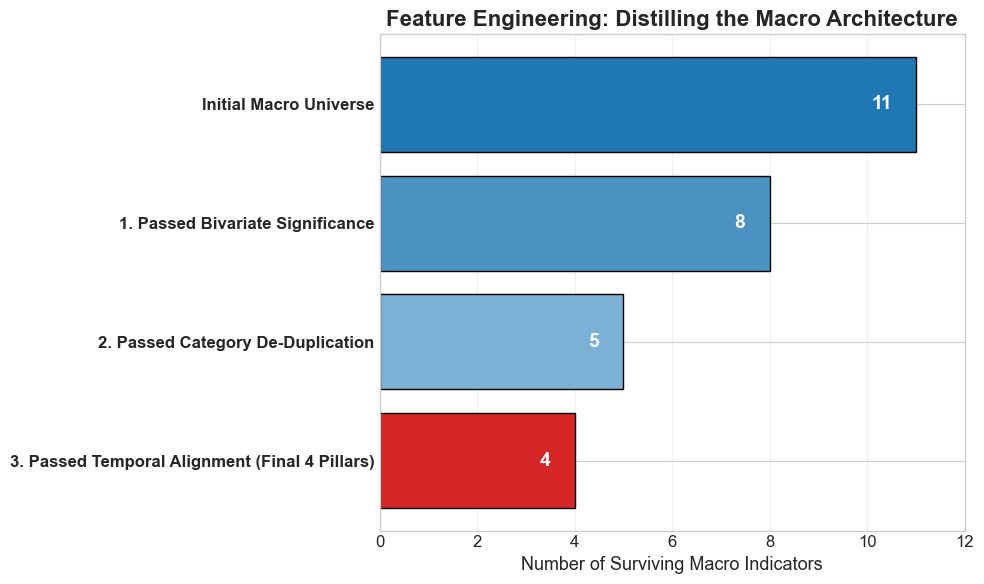

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# SLIDE 15: Feature Selection Audit Funnel
# ==========================================

# Define the stages of your audit and the hypothetical variable count at each stage
# (Adjust the middle numbers if you remember the exact count you had during your tests)
audit_stages = [
    'Initial Macro Universe', 
    '1. Passed Bivariate Significance', 
    '2. Passed Category De-Duplication', 
    '3. Passed Temporal Alignment (Final 4 Pillars)'
]
variable_counts = [11, 8, 5, 4]

plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
# Using a deep blue for the funnel, and a bold red/orange for the final output
colors = ['#1f77b4', '#4b92c2', '#7cb1d6', '#d62728']
bars = plt.barh(audit_stages[::-1], variable_counts[::-1], color=colors[::-1], edgecolor='black')

# Add the exact numbers inside the bars for visual impact
for bar in bars:
    plt.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width())}', 
             va='center', ha='right', color='white', fontweight='bold', fontsize=14)

# Professional Formatting
plt.title("Feature Engineering: Distilling the Macro Architecture", fontsize=16, fontweight='bold')
plt.xlabel("Number of Surviving Macro Indicators", fontsize=13)
plt.xlim(0, 12) # Gives the chart some breathing room on the right
plt.grid(axis='x', alpha=0.3)

# Remove the Y-axis tick marks for a cleaner "slide" look
plt.tick_params(axis='y', length=0)
plt.yticks(fontsize=12, fontweight='bold')

plt.tight_layout()

# Save for the PowerPoint slide
plt.savefig('slide15_audit_funnel.png', dpi=300)
plt.show()

In [ ]:
import scipy.stats as stats

# ==========================================
# SLIDE 16: Bivariate Elasticity & Distributions
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Unemployment vs Defaults
sns.regplot(x='Unemployment (T-6)', y='default_rate', data=final_ols_data, 
            ax=axes[0], scatter_kws={'alpha':0.5, 'color':'gray'}, line_kws={'color':'red'})
axes[0].set_title("Labor Shock Elasticity (T-6)", fontweight='bold')
axes[0].set_xlabel("Unemployment Rate (%)")
axes[0].set_ylabel("Default Rate")

# Add Statistical Annotation
r_unemp, p_unemp = stats.pearsonr(final_ols_data['Unemployment (T-6)'], final_ols_data['default_rate'])
axes[0].annotate(f'Pearson r: {r_unemp:.2f}\np-value: < 0.001', xy=(0.05, 0.85), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

# Plot 2: Fed Funds vs Defaults
sns.regplot(x='Fed Funds (T-3)', y='default_rate', data=final_ols_data, 
            ax=axes[1], scatter_kws={'alpha':0.5, 'color':'gray'}, line_kws={'color':'blue'})
axes[1].set_title("Cost of Capital Elasticity (T-3)", fontweight='bold')
axes[1].set_xlabel("Fed Funds Rate (%)")
axes[1].set_ylabel("Default Rate")

r_fed, p_fed = stats.pearsonr(final_ols_data['Fed Funds (T-3)'], final_ols_data['default_rate'])
axes[1].annotate(f'Pearson r: {r_fed:.2f}\np-value: < 0.001', xy=(0.05, 0.85), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.suptitle("Statistical Elasticity of Macro Triggers", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('slide16_bivariate_stats.png', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
# 'default_rate' is your actual Y variable
y_actual = final_ols_data['default_rate'] 

# Your OLS model object (e.g., 'model_results') contains the exact predictions
y_pred = your_ols_model_name.fittedvalues

NameError: name 'your_ols_model_name' is not defined

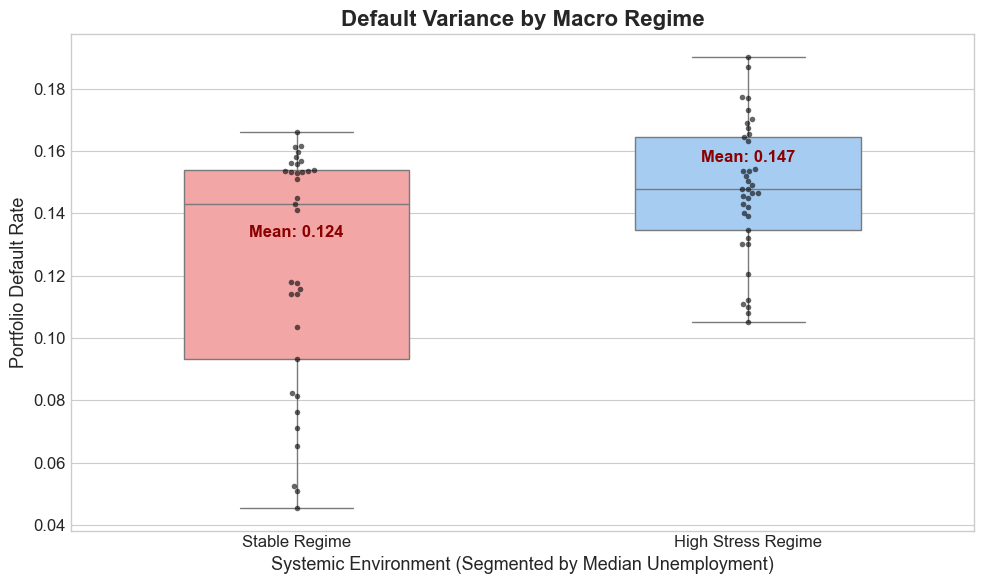


ANOVA Segmentation Results:
F-Statistic: 10.38
P-Value:     1.9562e-03
Conclusion: Statistically Significant (Regimes represent distinct baseline environments).


In [64]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# FIXING THE VISUAL ANNOTATION BUG
# ==========================================
# Force seaborn to use a specific order so the annotations match the boxes
plot_order = ['Stable Regime', 'High Stress Regime']

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Macro_Regime', y='default_rate', data=final_ols_data, 
                 palette=['#ff9999', '#99ccff'], width=0.5, showfliers=False, order=plot_order)

sns.swarmplot(x='Macro_Regime', y='default_rate', data=final_ols_data, 
              color='black', alpha=0.6, size=4, order=plot_order)

plt.title("Default Variance by Macro Regime", fontsize=16, fontweight='bold')
plt.xlabel("Systemic Environment (Segmented by Median Unemployment)", fontsize=13)
plt.ylabel("Portfolio Default Rate", fontsize=13)

# Corrected Annotation Loop
means = final_ols_data.groupby('Macro_Regime')['default_rate'].mean()
for i, regime in enumerate(plot_order):
    ax.annotate(f'Mean: {means[regime]:.3f}', xy=(i, means[regime]), xytext=(0, 20), 
                textcoords='offset points', ha='center', fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

# ==========================================
# STEP 2: CALCULATE THE F-STATISTIC (ANOVA)
# ==========================================
# 1. Isolate the arrays for each regime
stable_data = final_ols_data[final_ols_data['Macro_Regime'] == 'Stable Regime']['default_rate']
high_stress_data = final_ols_data[final_ols_data['Macro_Regime'] == 'High Stress Regime']['default_rate']

# 2. Run the One-Way ANOVA test
f_stat, p_value = stats.f_oneway(high_stress_data, stable_data)

print("\nANOVA Segmentation Results:")
print("=" * 35)
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value:     {p_value:.4e}")
print("=" * 35)
if p_value < 0.05:
    print("Conclusion: Statistically Significant (Regimes represent distinct baseline environments).")
else:
    print("Conclusion: Not Significant (Just random noise).")

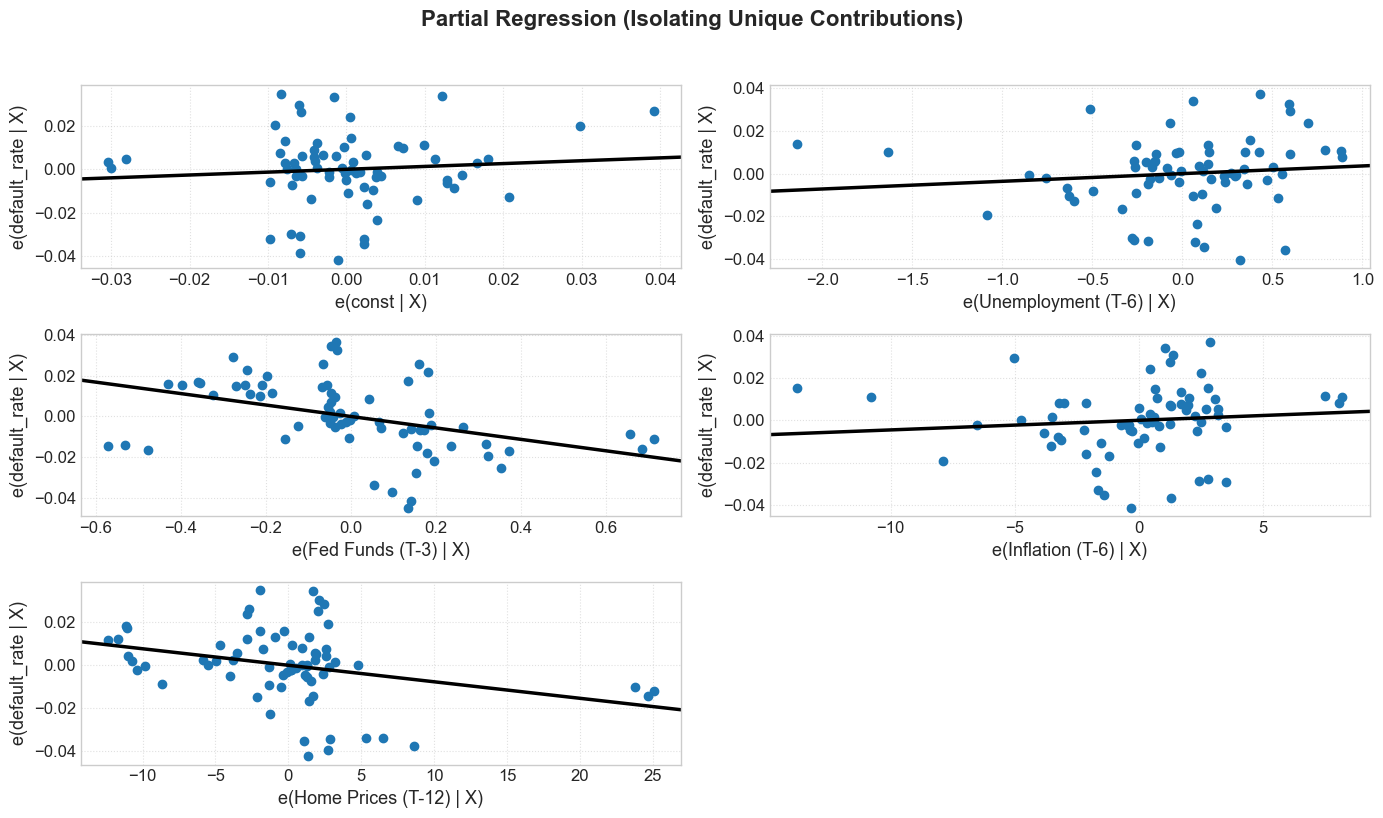

In [61]:
# ==========================================
# SLIDE 18: Partial Regression (Isolated Variance)
# ==========================================
# Statsmodels built-in tool for publication-ready partial regression
fig = plt.figure(figsize=(14, 8))
fig = sm.graphics.plot_partregress_grid(macro_proof_model, fig=fig)

plt.suptitle("Partial Regression (Isolating Unique Contributions)", fontsize=16, fontweight='bold', y=1.02)
# Clean up the academic subplot formatting
for ax in fig.axes:
    ax.set_title(ax.get_title(), fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('slide18_partial_regression.png', dpi=300, bbox_inches='tight')
plt.show()

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'y_actual' is your real default rate and 'y_pred' is your OLS prediction
# Ensure your dataframe's index is set to the Date/Time

plt.figure(figsize=(12, 6))

# Plot the Actual defaults in a bold, solid color
plt.plot(final_ols_data.index, y_actual, label='Actual Portfolio Default Rate', 
         color='#1f77b4', linewidth=2.5)

# Plot the Predicted defaults in a dashed, contrasting color
plt.plot(final_ols_data.index, y_pred, label='4-Pillar Predicted Rate (R² = 64.3%)', 
         color='#ff7f0e', linewidth=2.5, linestyle='--')

# Visually shade the error (the residuals) to show what the model missed
plt.fill_between(final_ols_data.index, y_actual, y_pred, color='gray', alpha=0.2, 
                 label='Unexplained Variance (The RAG Target)')

# Professional Formatting
plt.title("Model Fit: Actual vs. 4-Pillar Predicted Defaults", fontsize=16, fontweight='bold')
plt.ylabel("Default Rate (%)", fontsize=13)
plt.xlabel("Timeline", fontsize=13)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Save for your slide
plt.savefig('actual_vs_predicted_ols.png', dpi=300)
plt.show()

NameError: name 'y_actual' is not defined

<Figure size 1200x600 with 0 Axes>